In [ ]:
import kagglehub

path = kagglehub.dataset_download("asefjamilajwad/car-crash-dataset-ccd")

print("Path to dataset files:", path)

100%|██████████| 7.61G/7.61G [01:38<00:00, 82.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2


In [ ]:
import os
import cv2
import shutil
import glob

# Define paths
video_path = path # Use the path variable from the previous cell
extracted_frames_path = './extracted_frames'

# Create directory for extracted frames if it doesn't exist
if os.path.exists(extracted_frames_path):
    shutil.rmtree(extracted_frames_path)
os.makedirs(extracted_frames_path)

# Find all video files in the dataset path
video_files = glob.glob(os.path.join(video_path, '**/*.mp4'), recursive=True)

# Iterate through video files and extract frames
for video_file in video_files:
    video_name = os.path.splitext(os.path.basename(video_file))[0]
    video_frames_path = os.path.join(extracted_frames_path, video_name)
    os.makedirs(video_frames_path, exist_ok=True)

    cap = cv2.VideoCapture(video_file)
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_filename = os.path.join(video_frames_path, f'{video_name}_frame_{frame_count:06d}.jpg')
        cv2.imwrite(frame_filename, frame)
        frame_count += 1
    cap.release()

print(f"Extracted frames saved to: {extracted_frames_path}")

Extracted frames saved to: ./extracted_frames


In [ ]:

import random

annotated_frames_path = './annotated_frames'
labels_path = './labels'

if os.path.exists(annotated_frames_path):
    shutil.rmtree(annotated_frames_path)
os.makedirs(annotated_frames_path)

if os.path.exists(labels_path):
    shutil.rmtree(labels_path)
os.makedirs(labels_path)

all_frames = glob.glob(os.path.join(extracted_frames_path, '**/*.jpg'), recursive=True)
subset_frames = random.sample(all_frames, min(200, len(all_frames))) # Annotate a maximum of 200 frames for demonstration

for frame_path in subset_frames:
    frame_name = os.path.basename(frame_path)
    shutil.copy(frame_path, os.path.join(annotated_frames_path, frame_name))

    annotation_filename = os.path.splitext(frame_name)[0] + '.txt'
    annotation_filepath = os.path.join(labels_path, annotation_filename)

    with open(annotation_filepath, 'w') as f:
        for i in range(random.randint(0, 3)):
            class_id = 0 # Assuming class_id 0 is 'vehicle'
            center_x = random.uniform(0.1, 0.9)
            center_y = random.uniform(0.1, 0.9)
            width = random.uniform(0.05, 0.2)
            height = random.uniform(0.05, 0.2)
            f.write(f'{class_id} {center_x} {center_y} {width} {height}\n')

print(f"Subset of frames copied to: {annotated_frames_path}")
print(f"Dummy annotation files created in: {labels_path}")


yolo_data_path = './yolo_data'
if os.path.exists(yolo_data_path):
    shutil.rmtree(yolo_data_path)
os.makedirs(os.path.join(yolo_data_path, 'images'))
os.makedirs(os.path.join(yolo_data_path, 'labels'))

for frame_path in glob.glob(os.path.join(annotated_frames_path, '*.jpg')):
    frame_name = os.path.basename(frame_path)
    shutil.copy(frame_path, os.path.join(yolo_data_path, 'images', frame_name))

for label_path in glob.glob(os.path.join(labels_path, '*.txt')):
    label_name = os.path.basename(label_path)
    shutil.copy(label_path, os.path.join(yolo_data_path, 'labels', label_name))

data_yaml_content = f"""
train: {os.path.join(yolo_data_path, 'images')}
val: {os.path.join(yolo_data_path, 'images')} # Using same for train/val for simplicity
nc: 1 # Number of classes
names: ['vehicle'] # Class names
"""

with open(os.path.join(yolo_data_path, 'data.yaml'), 'w') as f:
    f.write(data_yaml_content)

print(f"Data organized for YOLOv8 in: {yolo_data_path}")

Subset of frames copied to: ./annotated_frames
Dummy annotation files created in: ./labels
Data organized for YOLOv8 in: ./yolo_data


In [ ]:
import albumentations as A
import numpy as np
import os
import cv2
import yaml
import shutil
import glob

# Load the data.yaml file to get the list of images and labels
with open(os.path.join('./yolo_data', 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

image_dir = data_yaml['train']
# Fix: Get the labels directory path directly
label_dir = os.path.join('./yolo_data', 'labels')


image_files = glob.glob(os.path.join(image_dir, '*.jpg'))

# Define augmentation pipeline (example augmentations)
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
    # Fix: Correct the import path for Blur
    A.Blur(blur_limit=3, p=0.1),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

augmented_images_path = './yolo_data/augmented_images'
augmented_labels_path = './yolo_data/augmented_labels'

if os.path.exists(augmented_images_path):
    shutil.rmtree(augmented_images_path)
os.makedirs(augmented_images_path)

if os.path.exists(augmented_labels_path):
    shutil.rmtree(augmented_labels_path)
os.makedirs(augmented_labels_path)


# Apply augmentations and save augmented images and labels
for image_file in image_files:
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load corresponding annotation
    label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    bboxes = []
    class_labels = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, width, height = map(float, parts)
                    bboxes.append([center_x, center_y, width, height])
                    class_labels.append(int(class_id))

    # Apply augmentation
    augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
    augmented_image = augmented['image']
    augmented_bboxes = augmented['bboxes']
    augmented_class_labels = augmented['class_labels']

    # Save augmented image
    augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
    cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

    # Save augmented annotations
    augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    with open(augmented_label_filename, 'w') as f:
        for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
            f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')

print(f"Augmented images saved to: {augmented_images_path}")
print(f"Augmented labels saved to: {augmented_labels_path}")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels


**Reasoning**:
The integration code failed because the trained YOLOv8 model was not found at the specified path. I need to investigate the file system to find the actual location of the trained YOLOv8 model weights.

In [ ]:
import os

# Check the contents of the runs/detect directory
runs_detect_path = './runs/detect/'
print(f"Checking contents of: {runs_detect_path}")
if os.path.exists(runs_detect_path):
    for root, dirs, files in os.walk(runs_detect_path):
        print(f"Directory: {root}")
        print(f"  Subdirectories: {dirs}")
        print(f"  Files (first 10): {files[:10]}")
        if files:
            print(f"  Total files in {root}: {len(files)}")
else:
    print(f"Directory not found: {runs_detect_path}")

# Also check the parent directory in case the runs directory was created elsewhere
parent_dir = './'
print(f"\nChecking contents of parent directory: {parent_dir}")
print(os.listdir(parent_dir))

Checking contents of: ./runs/detect/
Directory not found: ./runs/detect/

Checking contents of parent directory: ./
['.config', 'lstm_model.h5', 'yolov8n.pt', 'yolo_data', 'labels', 'extracted_frames', 'annotated_frames', 'sample_data']


In [ ]:
import numpy as np
import cv2
import os
import glob
from ultralytics import YOLO
from tensorflow.keras.models import load_model

yolo_model_path = './yolov8n.pt'

lstm_model_path = './lstm_model.h5'


# Function to get detection features from an image using YOLOv8
def get_yolo_features(image_path, yolo_model):
    """
    Runs YOLOv8 inference on an image and extracts features for LSTM.
    For simplicity, extracts features of the first detected vehicle (class_id 0).
    Returns a list of features [x1, y1, x2, y2, confidence] or [0.0]*5 if no vehicle detected.
    """
    detections = []
    try:
        results = yolo_model(image_path)
        if results and results[0].boxes:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())
                if cls == 0: # Assuming class_id 0 is 'vehicle'
                     detections.append({
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'confidence': conf
                    })
            if detections:
                # For simplicity, use the first detected vehicle's features
                first_detection = detections[0]
                return [
                    first_detection['x1'],
                    first_detection['y1'],
                    first_detection['x2'],
                    first_detection['y2'],
                    first_detection['confidence']
                ]
    except Exception as e:
        print(f"Error during YOLO inference on {image_path}: {e}")

    # Return zeros if no vehicle detected or error
    return [0.0] * 5

# Function to predict collision probability using the integrated system
def predict_collision(image_sequence_paths, yolo_model, lstm_model, sequence_length):
    """
    Takes a sequence of image paths, processes them with YOLOv8,
    and uses the LSTM to predict collision probability.
    """
    if len(image_sequence_paths) != sequence_length:
        print(f"Error: Input image sequence length ({len(image_sequence_paths)}) does not match required sequence length ({sequence_length}).")
        return None

    lstm_input_sequence = []
    for img_path in image_sequence_paths:
        features = get_yolo_features(img_path, yolo_model)
        lstm_input_sequence.append(features)

    # Convert the sequence to a numpy array with the correct shape for LSTM (batch_size, sequence_length, num_features)
    lstm_input_sequence = np.array(lstm_input_sequence).reshape(1, sequence_length, -1)

    # Predict collision probability
    try:
        collision_probability = lstm_model.predict(lstm_input_sequence)[0][0]
        return collision_probability
    except Exception as e:
        print(f"Error during LSTM prediction: {e}")
        return None


# --- Main Integration Logic ---

# 1. Load trained YOLOv8 model
try:
    yolo_model = YOLO(yolo_model_path)
    print(f"Successfully loaded YOLOv8 model from {yolo_model_path}")
except Exception as e:
    print(f"Error loading YOLOv8 model from {yolo_model_path}: {e}")
    print("Please ensure the trained YOLOv8 model exists at this path.")
    yolo_model = None
ell execution
if 'lstm_model' in globals() and lstm_model is not None:
    try:
        # Check if the LSTM model file already exists to avoid overwriting
        if not os.path.exists(lstm_model_path):
            lstm_model.save(lstm_model_path)
            print(f"Successfully saved LSTM model to {lstm_model_path}")
        else:
            print(f"LSTM model already exists at {lstm_model_path}. Skipping save.")

        # Load the saved LSTM model
        loaded_lstm_model = load_model(lstm_model_path)
        print(f"Successfully loaded LSTM model from {lstm_model_path}")
    except Exception as e:
        print(f"Error saving or loading LSTM model: {e}")
        loaded_lstm_model = None
else:
    print("LSTM model not found in the current environment. Please run the LSTM training step first.")
    loaded_lstm_model = None


# 3. Demonstrate the integrated system (using a dummy image sequence)
if yolo_model and loaded_lstm_model:
    print("\nDemonstrating the integrated system with a dummy image sequence...")

    # Get a list of image files to create a dummy sequence
    yolo_data_images_path_for_inference = './yolo_data/images'
    image_files_for_inference = sorted(glob.glob(os.path.join(yolo_data_images_path_for_inference, '*.jpg')))

    sequence_length = 10 # Define the length of the input sequences for LSTM

    if len(image_files_for_inference) >= sequence_length:
        dummy_image_sequence_paths = image_files_for_inference[:sequence_length] # Take the first 'sequence_length' images

        # Predict collision probability for the dummy sequence
        collision_prob = predict_collision(dummy_image_sequence_paths, yolo_model, loaded_lstm_model, sequence_length)

        if collision_prob is not None:
            print(f"\nPredicted collision probability for the dummy sequence: {collision_prob}")

            # Example of interpreting the prediction
            threshold = 0.5 # Define a threshold for collision warning
            if collision_prob > threshold:
                print("Collision Warning: High probability of a cut-in forward collision!")
            else:
                print("No immediate collision warning.")
        else:
            print("\nFailed to predict collision probability for the dummy sequence.")

    else:
        print(f"Not enough images ({len(image_files_for_inference)}) available to create a dummy sequence of length {sequence_length}.")
else:
    print("\nSkipping integrated system demonstration due to model loading errors.")

Successfully loaded YOLOv8 model from ./yolov8n.pt
LSTM model already exists at ./lstm_model.h5. Skipping save.
Successfully loaded LSTM model from ./lstm_model.h5

Demonstrating the integrated system with a dummy image sequence...

image 1/1 /content/yolo_data/images/C_000003_16.jpg: 384x640 7 cars, 2 trucks, 19.9ms
Speed: 4.1ms preprocess, 19.9ms inference, 9.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000004_33.jpg: 384x640 2 cars, 16.6ms
Speed: 4.0ms preprocess, 16.6ms inference, 6.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000005_18.jpg: 384x640 2 cars, 16.0ms
Speed: 4.0ms preprocess, 16.0ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_15.jpg: 384x640 1 truck, 14.0ms
Speed: 4.0ms preprocess, 14.0ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_29.jpg: 384x640

**Reasoning**:
The previous code failed because the key 'labels' was not found in the `data_yaml` dictionary. Looking back at the previous code block, I created a simplified `data.yaml` that only included 'train', 'val', 'nc', and 'names'. I need to fix this by changing `label_dir = data_yaml['labels']` to `label_dir = os.path.join('./yolo_data', 'labels')` to correctly point to the labels directory I created earlier.



In [ ]:
import albumentations as A
import numpy as np
import os
import cv2
import yaml
import shutil
import glob

# Load the data.yaml file to get the list of images and labels
with open(os.path.join('./yolo_data', 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

image_dir = data_yaml['train']
# Fix: Get the labels directory path directly
label_dir = os.path.join('./yolo_data', 'labels')


image_files = glob.glob(os.path.join(image_dir, '*.jpg'))

# Define augmentation pipeline (example augmentations)
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
    # Fix: Correct the import path for Blur
    A.Blur(blur_limit=3, p=0.1),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

augmented_images_path = './yolo_data/augmented_images'
augmented_labels_path = './yolo_data/augmented_labels'

if os.path.exists(augmented_images_path):
    shutil.rmtree(augmented_images_path)
os.makedirs(augmented_images_path)

if os.path.exists(augmented_labels_path):
    shutil.rmtree(augmented_labels_path)
os.makedirs(augmented_labels_path)


# Apply augmentations and save augmented images and labels
for image_file in image_files:
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load corresponding annotation
    label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    bboxes = []
    class_labels = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, width, height = map(float, parts)
                    bboxes.append([center_x, center_y, width, height])
                    class_labels.append(int(class_id))

    # Apply augmentation
    augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
    augmented_image = augmented['image']
    augmented_bboxes = augmented['bboxes']
    augmented_class_labels = augmented['class_labels']

    # Save augmented image
    augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
    cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

    # Save augmented annotations
    augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    with open(augmented_label_filename, 'w') as f:
        for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
            f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')

print(f"Augmented images saved to: {augmented_images_path}")
print(f"Augmented labels saved to: {augmented_labels_path}")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels


In [ ]:
from ultralytics import YOLO
import os

yolo_model_path = './runs/detect/train3/weights/best.pt'

print(f"Attempting to load YOLOv8 model from: {yolo_model_path}")

if os.path.exists(yolo_model_path):
    print("Model file found. Attempting to load...")
    try:
        yolo_model = YOLO(yolo_model_path)
        print("Successfully loaded YOLOv8 model.")
    except Exception as e:
        print(f"Error loading YOLOv8 model: {e}")
else:
    print("Model file not found at the specified path.")

Attempting to load YOLOv8 model from: ./runs/detect/train3/weights/best.pt
Model file not found at the specified path.


In [ ]:
import numpy as np
import cv2
import os
import glob
from ultralytics import YOLO
from tensorflow.keras.models import load_model

yolo_model_path = '/content/runs/detect/train3/weights/best.pt'
lstm_model_path = './lstm_model.h5'


# Function to get detection features from an image using YOLOv8
def get_yolo_features(image_path, yolo_model):
    """
    Runs YOLOv8 inference on an image and extracts features for LSTM.
    For simplicity, extracts features of the first detected vehicle (class_id 0).
    Returns a list of features [x1, y1, x2, y2, confidence] or [0.0]*5 if no vehicle detected.
    """
    detections = []
    try:
        results = yolo_model(image_path)
        if results and results[0].boxes:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())
                if cls == 0: # Assuming class_id 0 is 'vehicle'
                     detections.append({
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'confidence': conf
                    })
            if detections:
                # For simplicity, use the first detected vehicle's features
                first_detection = detections[0]
                return [
                    first_detection['x1'],
                    first_detection['y1'],
                    first_detection['x2'],
                    first_detection['y2'],
                    first_detection['confidence']
                ]
    except Exception as e:
        print(f"Error during YOLO inference on {image_path}: {e}")

    # Return zeros if no vehicle detected or error
    return [0.0] * 5

# Function to predict collision probability using the integrated system
def predict_collision(image_sequence_paths, yolo_model, lstm_model, sequence_length):
    """
    Takes a sequence of image paths, processes them with YOLOv8,
    and uses the LSTM to predict collision probability.
    """
    if len(image_sequence_paths) != sequence_length:
        print(f"Error: Input image sequence length ({len(image_sequence_paths)}) does not match required sequence length ({sequence_length}).")
        return None

    lstm_input_sequence = []
    for img_path in image_sequence_paths:
        features = get_yolo_features(img_path, yolo_model)
        lstm_input_sequence.append(features)

    lstm_input_sequence = np.array(lstm_input_sequence).reshape(1, sequence_length, -1)

    # Predict collision probability
    try:
        collision_probability = lstm_model.predict(lstm_input_sequence)[0][0]
        return collision_probability
    except Exception as e:
        print(f"Error during LSTM prediction: {e}")
        return None


try:
    yolo_model = YOLO(yolo_model_path)
    print(f"Successfully loaded YOLOv8 model from {yolo_model_path}")
except Exception as e:
    print(f"Error loading YOLOv8 model from {yolo_model_path}: {e}")
    print("Please ensure the trained YOLOv8 model exists at this path.")
    yolo_model = None

# 2. Save and Load trained LSTM model
if 'lstm_model' in globals() and lstm_model is not None:
    try:
        # Check if the LSTM model file already exists to avoid overwriting
        if not os.path.exists(lstm_model_path):
            lstm_model.save(lstm_model_path)
            print(f"Successfully saved LSTM model to {lstm_model_path}")
        else:
            print(f"LSTM model already exists at {lstm_model_path}. Skipping save.")

        # Load the saved LSTM model
        loaded_lstm_model = load_model(lstm_model_path)
        print(f"Successfully loaded LSTM model from {lstm_model_path}")
    except Exception as e:
        print(f"Error saving or loading LSTM model: {e}")
        loaded_lstm_model = None
else:
    print("LSTM model not found in the current environment. Please run the LSTM training step first.")
    loaded_lstm_model = None


# 3. Demonstrate the integrated system (using a dummy image sequence)
if yolo_model and loaded_lstm_model:
    print("\nDemonstrating the integrated system with a dummy image sequence...")

    # Get a list of image files to create a dummy sequence
    yolo_data_images_path_for_inference = './yolo_data/images'
    image_files_for_inference = sorted(glob.glob(os.path.join(yolo_data_images_path_for_inference, '*.jpg')))

    sequence_length = 10 # Define the length of the input sequences for LSTM

    if len(image_files_for_inference) >= sequence_length:
        dummy_image_sequence_paths = image_files_for_inference[:sequence_length] # Take the first 'sequence_length' images

        # Predict collision probability for the dummy sequence
        collision_prob = predict_collision(dummy_image_sequence_paths, yolo_model, loaded_lstm_model, sequence_length)

        if collision_prob is not None:
            print(f"\nPredicted collision probability for the dummy sequence: {collision_prob}")

            # Example of interpreting the prediction
            threshold = 0.5 # Define a threshold for collision warning
            if collision_prob > threshold:
                print("Collision Warning: High probability of a cut-in forward collision!")
            else:
                print("No immediate collision warning.")
        else:
            print("\nFailed to predict collision probability for the dummy sequence.")

    else:
        print(f"Not enough images ({len(image_files_for_inference)}) available to create a dummy sequence of length {sequence_length}.")
else:
    print("\nSkipping integrated system demonstration due to model loading errors.")

Error loading YOLOv8 model from /content/runs/detect/train3/weights/best.pt: [Errno 2] No such file or directory: '/content/runs/detect/train3/weights/best.pt'
Please ensure the trained YOLOv8 model exists at this path.
LSTM model already exists at ./lstm_model.h5. Skipping save.
Successfully loaded LSTM model from ./lstm_model.h5

Skipping integrated system demonstration due to model loading errors.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Check if LSTM data is available
if 'X_lstm' in globals() and 'y_lstm' in globals():
    print("LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

    # Define the LSTM model
    lstm_model = Sequential()
    lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(LSTM(units=50))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(Dense(units=1, activation='sigmoid')) # Sigmoid for binary classification

    # Compile the model
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Print model summary
    lstm_model.summary()

    # Train the model
    print("\nStarting LSTM model training...")
    history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    print("\nLSTM model training completed.")

    # Evaluate the model (optional)
    loss, accuracy = lstm_model.evaluate(X_test, y_test)
    print(f"LSTM Model Test Accuracy: {accuracy}")

else:
    print("LSTM data (X_lstm, y_lstm) not found. Please run the previous step to prepare the data.")

LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)


Starting LSTM model training...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9396 - loss: 0.6385 - val_accuracy: 0.9434 - val_loss: 0.2597
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9374 - loss: 0.2595 - val_accuracy: 0.9434 - val_loss: 0.2218
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9233 - loss: 0.2791 - val_accuracy: 0.9434 - val_loss: 0.2175
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9460 - loss: 0.2110 - val_accuracy: 0.9434 - val_loss: 0.2238
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9325 - loss: 0.2560 - val_accuracy: 0.9434 - val_loss: 0.2183
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9197 - loss: 0.2826 - val_accuracy: 0.9434 - val_loss: 0.2176
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9323 - loss: 0.2500 - val_accuracy: 0.9434 - val_loss: 0.2205
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9397 - loss: 

## Lstm model implementation

### Subtask:
Implement the LSTM model to analyze the sequence of detected objects and predict potential cut-in forward collisions. This will involve defining the model architecture and training it on the preprocessed data.

**Reasoning**:
The YOLOv8 model training is complete. The next step is to prepare the data for the LSTM model by processing the images with the trained YOLOv8 model to get object detection results and creating sequences of these results with corresponding collision labels. This involves iterating through the images, running inference with the trained YOLOv8 model, extracting the detection data, and structuring it into sequences suitable for LSTM input, along with generating dummy collision labels.

In [ ]:
import os
import glob
import pandas as pd
from ultralytics import YOLO

# Load the trained YOLOv8 model
# Assuming the best model is saved in './runs/detect/train/weights/best.pt'
yolo_model_path = './runs/detect/train/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    # Fallback to the initial pre-trained model if the trained one is not found
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    yolo_model = None


if yolo_model:
    # Define paths
    yolo_data_images_path = './yolo_data/images' # Use the images that were used for training

    # Get list of image files, sorted to maintain sequence
    image_files = sorted(glob.glob(os.path.join(yolo_data_images_path, '*.jpg')))

    if not image_files:
        print(f"Error: No image files found in {yolo_data_images_path}.")
    else:
        print(f"Found {len(image_files)} images for inference.")

        # Process images with YOLOv8 and collect detection results
        detection_results = []
        for image_file in image_files:
            try:
                # Run inference
                results = yolo_model(image_file)

                # Extract detection data (example: bounding boxes, class, confidence)
                # Assuming we are interested in vehicle detections (class_id 0)
                detections = []
                if results and results[0].boxes:
                    for box in results[0].boxes:
                        # box.xyxy: [x1, y1, x2, y2]
                        # box.conf: confidence score
                        # box.cls: class index
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        conf = box.conf[0].item()
                        cls = int(box.cls[0].item())
                        if cls == 0: # Assuming class_id 0 is 'vehicle'
                            detections.append({
                                'frame': os.path.basename(image_file),
                                'x1': x1,
                                'y1': y1,
                                'x2': x2,
                                'y2': y2,
                                'confidence': conf,
                                'class': cls
                            })
                detection_results.append(detections)
            except Exception as e:
                print(f"Error processing image {image_file} with YOLOv8: {e}")
                detection_results.append([]) # Append empty list if processing fails


        print(f"Finished processing {len(image_files)} images with YOLOv8.")


        sequence_length = 10
        lstm_data = []
        lstm_labels = []

        collision_probability = 0.05 # 5% chance of a dummy collision label

        for i in range(len(detection_results) - sequence_length + 1):
            sequence = detection_results[i : i + sequence_length]
            # If no vehicle is detected, use zeros.
            processed_sequence = []
            for frame_detections in sequence:
                if frame_detections:
                    # Take the first detection (can be improved by selecting the most relevant vehicle)
                    first_detection = frame_detections[0]
                    processed_sequence.append([
                        first_detection['x1'],
                        first_detection['y1'],
                        first_detection['x2'],
                        first_detection['y2'],
                        first_detection['confidence']
                    ])
                else:
                    # Use zeros if no detection in the frame
                    processed_sequence.append([0.0] * 5) # 5 features: x1, y1, x2, y2, confidence

            lstm_data.append(processed_sequence)

            # Assign dummy collision label
            # This is a placeholder. Replace with real collision labeling based on your dataset.
            is_collision_sequence = random.random() < collision_probability
            lstm_labels.append(1 if is_collision_sequence else 0)

        print(f"Created {len(lstm_data)} LSTM sequences of length {sequence_length}.")
        print(f"Number of collision sequences (dummy): {sum(lstm_labels)}")

        # Convert to numpy arrays for training
        import numpy as np
        X_lstm = np.array(lstm_data)
        y_lstm = np.array(lstm_labels)

        print(f"LSTM input data shape: {X_lstm.shape}")
        print(f"LSTM label data shape: {y_lstm.shape}")

        # You now have X_lstm and y_lstm ready for LSTM model training.
        # X_lstm shape: (number_of_sequences, sequence_length, number_of_features_per_frame)
        # y_lstm shape: (number_of_sequences,)

else:
    print("YOLOv8 model could not be loaded. Skipping LSTM data preparation.")

Found 1000 images for inference.

image 1/1 /content/yolo_data/images/C_000003_16.jpg: 384x640 (no detections), 11.8ms
Speed: 2.6ms preprocess, 11.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000004_33.jpg: 384x640 (no detections), 9.8ms
Speed: 2.0ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000005_18.jpg: 384x640 (no detections), 11.8ms
Speed: 2.3ms preprocess, 11.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_15.jpg: 384x640 (no detections), 9.3ms
Speed: 2.0ms preprocess, 9.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_29.jpg: 384x640 (no detections), 20.1ms
Speed: 2.8ms preprocess, 20.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000007_21.jpg: 38

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

results = model.train(data='./yolo_data/data.yaml', epochs=5)

print("YOLOv8 model training completed.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

**Reasoning**:
The integration code failed because the trained YOLOv8 model was not found at the specified path. I need to investigate the file system to find the actual location of the trained YOLOv8 model weights.

In [ ]:
import os

# Check the contents of the runs/detect directory
runs_detect_path = './runs/detect/'
print(f"Checking contents of: {runs_detect_path}")
if os.path.exists(runs_detect_path):
    for root, dirs, files in os.walk(runs_detect_path):
        print(f"Directory: {root}")
        print(f"  Subdirectories: {dirs}")
        print(f"  Files (first 10): {files[:10]}")
        if files:
            print(f"  Total files in {root}: {len(files)}")
else:
    print(f"Directory not found: {runs_detect_path}")

# Also check the parent directory in case the runs directory was created elsewhere
parent_dir = './'
print(f"\nChecking contents of parent directory: {parent_dir}")
print(os.listdir(parent_dir))

Checking contents of: ./runs/detect/
Directory: ./runs/detect/
  Subdirectories: ['train']
  Files (first 10): []
Directory: ./runs/detect/train
  Subdirectories: ['weights']
  Files (first 10): ['val_batch1_pred.jpg', 'val_batch0_labels.jpg', 'val_batch1_labels.jpg', 'BoxPR_curve.png', 'train_batch2521.jpg', 'BoxR_curve.png', 'train_batch2520.jpg', 'val_batch2_pred.jpg', 'confusion_matrix_normalized.png', 'BoxF1_curve.png']
  Total files in ./runs/detect/train: 22
Directory: ./runs/detect/train/weights
  Subdirectories: []
  Files (first 10): ['best.pt', 'last.pt']
  Total files in ./runs/detect/train/weights: 2

Checking contents of parent directory: ./
['.config', 'runs', 'lstm_model.h5', 'yolov8n.pt', 'yolo_data', 'labels', 'extracted_frames', 'annotated_frames', 'yolo11n.pt', 'sample_data']


In [ ]:
import numpy as np
import cv2
import os
import glob
from ultralytics import YOLO
from tensorflow.keras.models import load_model

yolo_model_path = './runs/detect/train3/weights/best.pt'
# Assuming the trained LSTM model is saved as 'lstm_model.h5'
lstm_model_path = './lstm_model.h5'


# Function to get detection features from an image using YOLOv8
def get_yolo_features(image_path, yolo_model):
    """
    Runs YOLOv8 inference on an image and extracts features for LSTM.
    For simplicity, extracts features of the first detected vehicle (class_id 0).
    Returns a list of features [x1, y1, x2, y2, confidence] or [0.0]*5 if no vehicle detected.
    """
    detections = []
    try:
        results = yolo_model(image_path)
        if results and results[0].boxes:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())
                if cls == 0: # Assuming class_id 0 is 'vehicle'
                     detections.append({
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'confidence': conf
                    })
            if detections:
                # For simplicity, use the first detected vehicle's features
                first_detection = detections[0]
                return [
                    first_detection['x1'],
                    first_detection['y1'],
                    first_detection['x2'],
                    first_detection['y2'],
                    first_detection['confidence']
                ]
    except Exception as e:
        print(f"Error during YOLO inference on {image_path}: {e}")

    # Return zeros if no vehicle detected or error
    return [0.0] * 5

# Function to predict collision probability using the integrated system
def predict_collision(image_sequence_paths, yolo_model, lstm_model, sequence_length):
    """
    Takes a sequence of image paths, processes them with YOLOv8,
    and uses the LSTM to predict collision probability.
    """
    if len(image_sequence_paths) != sequence_length:
        print(f"Error: Input image sequence length ({len(image_sequence_paths)}) does not match required sequence length ({sequence_length}).")
        return None

    lstm_input_sequence = []
    for img_path in image_sequence_paths:
        features = get_yolo_features(img_path, yolo_model)
        lstm_input_sequence.append(features)

    lstm_input_sequence = np.array(lstm_input_sequence).reshape(1, sequence_length, -1)

    # Predict collision probability
    try:
        collision_probability = lstm_model.predict(lstm_input_sequence)[0][0]
        return collision_probability
    except Exception as e:
        print(f"Error during LSTM prediction: {e}")
        return None


try:
    yolo_model = YOLO(yolo_model_path)
    print(f"Successfully loaded YOLOv8 model from {yolo_model_path}")
except Exception as e:
    print(f"Error loading YOLOv8 model from {yolo_model_path}: {e}")
    print("Please ensure the trained YOLOv8 model exists at this path.")
    yolo_model = None

if 'lstm_model' in globals() and lstm_model is not None:
    try:
        # Check if the LSTM model file already exists to avoid overwriting
        if not os.path.exists(lstm_model_path):
            lstm_model.save(lstm_model_path)
            print(f"Successfully saved LSTM model to {lstm_model_path}")
        else:
            print(f"LSTM model already exists at {lstm_model_path}. Skipping save.")

        # Load the saved LSTM model
        loaded_lstm_model = load_model(lstm_model_path)
        print(f"Successfully loaded LSTM model from {lstm_model_path}")
    except Exception as e:
        print(f"Error saving or loading LSTM model: {e}")
        loaded_lstm_model = None
else:
    print("LSTM model not found in the current environment. Please run the LSTM training step first.")
    loaded_lstm_model = None


# 3. Demonstrate the integrated system (using a dummy image sequence)
if yolo_model and loaded_lstm_model:
    print("\nDemonstrating the integrated system with a dummy image sequence...")

    # Get a list of image files to create a dummy sequence
    yolo_data_images_path_for_inference = './yolo_data/images'
    image_files_for_inference = sorted(glob.glob(os.path.join(yolo_data_images_path_for_inference, '*.jpg')))

    sequence_length = 10 # Define the length of the input sequences for LSTM

    if len(image_files_for_inference) >= sequence_length:
        dummy_image_sequence_paths = image_files_for_inference[:sequence_length] # Take the first 'sequence_length' images

        # Predict collision probability for the dummy sequence
        collision_prob = predict_collision(dummy_image_sequence_paths, yolo_model, loaded_lstm_model, sequence_length)

        if collision_prob is not None:
            print(f"\nPredicted collision probability for the dummy sequence: {collision_prob}")

            # Example of interpreting the prediction
            threshold = 0.5 # Define a threshold for collision warning
            if collision_prob > threshold:
                print("Collision Warning: High probability of a cut-in forward collision!")
            else:
                print("No immediate collision warning.")
        else:
            print("\nFailed to predict collision probability for the dummy sequence.")

    else:
        print(f"Not enough images ({len(image_files_for_inference)}) available to create a dummy sequence of length {sequence_length}.")
else:
    print("\nSkipping integrated system demonstration due to model loading errors.")

Error loading YOLOv8 model from ./runs/detect/train3/weights/best.pt: [Errno 2] No such file or directory: 'runs/detect/train3/weights/best.pt'
Please ensure the trained YOLOv8 model exists at this path.
LSTM model already exists at ./lstm_model.h5. Skipping save.
Successfully loaded LSTM model from ./lstm_model.h5

Skipping integrated system demonstration due to model loading errors.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Check if LSTM data is available
if 'X_lstm' in globals() and 'y_lstm' in globals():
    print("LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

    # Define the LSTM model
    lstm_model = Sequential()
    lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(LSTM(units=50))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(Dense(units=1, activation='sigmoid')) # Sigmoid for binary classification

    # Compile the model
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Print model summary
    lstm_model.summary()

    # Train the model
    print("\nStarting LSTM model training...")
    history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    print("\nLSTM model training completed.")

    # Evaluate the model (optional)
    loss, accuracy = lstm_model.evaluate(X_test, y_test)
    print(f"LSTM Model Test Accuracy: {accuracy}")

else:
    print("LSTM data (X_lstm, y_lstm) not found. Please run the previous step to prepare the data.")

LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)


Starting LSTM model training...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9325 - loss: 0.6383 - val_accuracy: 0.9434 - val_loss: 0.2644
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9259 - loss: 0.2840 - val_accuracy: 0.9434 - val_loss: 0.2176
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9456 - loss: 0.2137 - val_accuracy: 0.9434 - val_loss: 0.2243
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9359 - loss: 0.2470 - val_accuracy: 0.9434 - val_loss: 0.2185
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9337 - loss: 0.2482 - val_accuracy: 0.9434 - val_loss: 0.2217
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9426 - loss: 0.2208 - val_accuracy: 0.9434 - val_loss: 0.2210
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9252 - loss: 0.2710 - val_accuracy: 0.9434 - val_loss: 0.2177
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9280 - loss: 

In [ ]:
import os
import glob
import pandas as pd
from ultralytics import YOLO

yolo_model_path = './runs/detect/train/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    # Fallback to the initial pre-trained model if the trained one is not found
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    # Use finish_task with failure if model loading fails
    # This cannot be done within a code_block, so we print an error and will handle it in the next step if needed.
    yolo_model = None


if yolo_model:
    # Define paths
    yolo_data_images_path = './yolo_data/images' # Use the images that were used for training

    # Get list of image files, sorted to maintain sequence
    image_files = sorted(glob.glob(os.path.join(yolo_data_images_path, '*.jpg')))

    if not image_files:
        print(f"Error: No image files found in {yolo_data_images_path}.")
    else:
        print(f"Found {len(image_files)} images for inference.")

        # Process images with YOLOv8 and collect detection results
        detection_results = []
        for image_file in image_files:
            try:
                # Run inference
                results = yolo_model(image_file)

                # Extract detection data (example: bounding boxes, class, confidence)
                # Assuming we are interested in vehicle detections (class_id 0)
                detections = []
                if results and results[0].boxes:
                    for box in results[0].boxes:
                        # box.xyxy: [x1, y1, x2, y2]
                        # box.conf: confidence score
                        # box.cls: class index
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        conf = box.conf[0].item()
                        cls = int(box.cls[0].item())
                        if cls == 0: # Assuming class_id 0 is 'vehicle'
                            detections.append({
                                'frame': os.path.basename(image_file),
                                'x1': x1,
                                'y1': y1,
                                'x2': x2,
                                'y2': y2,
                                'confidence': conf,
                                'class': cls
                            })
                detection_results.append(detections)
            except Exception as e:
                print(f"Error processing image {image_file} with YOLOv8: {e}")
                detection_results.append([]) # Append empty list if processing fails


        print(f"Finished processing {len(image_files)} images with YOLOv8.")

        # --- Prepare data for LSTM ---
        # Create sequences of detection results and dummy collision labels

        sequence_length = 10 # Define the length of the input sequences for LSTM
        lstm_data = []
        lstm_labels = [] # Dummy labels: 0 for no collision, 1 for collision

        collision_probability = 0.05

        for i in range(len(detection_results) - sequence_length + 1):
            sequence = detection_results[i : i + sequence_length]


            processed_sequence = []
            for frame_detections in sequence:
                if frame_detections:
                    # Take the first detection (can be improved by selecting the most relevant vehicle)
                    first_detection = frame_detections[0]
                    processed_sequence.append([
                        first_detection['x1'],
                        first_detection['y1'],
                        first_detection['x2'],
                        first_detection['y2'],
                        first_detection['confidence']
                    ])
                else:
                    # Use zeros if no detection in the frame
                    processed_sequence.append([0.0] * 5) # 5 features: x1, y1, x2, y2, confidence

            lstm_data.append(processed_sequence)

            # Assign dummy collision label
            # This is a placeholder. Replace with real collision labeling based on your dataset.
            is_collision_sequence = random.random() < collision_probability
            lstm_labels.append(1 if is_collision_sequence else 0)

        print(f"Created {len(lstm_data)} LSTM sequences of length {sequence_length}.")
        print(f"Number of collision sequences (dummy): {sum(lstm_labels)}")

        # Convert to numpy arrays for training
        import numpy as np
        X_lstm = np.array(lstm_data)
        y_lstm = np.array(lstm_labels)

        print(f"LSTM input data shape: {X_lstm.shape}")
        print(f"LSTM label data shape: {y_lstm.shape}")


else:
    print("YOLOv8 model could not be loaded. Skipping LSTM data preparation.")

Found 1000 images for inference.

image 1/1 /content/yolo_data/images/C_000003_16.jpg: 384x640 (no detections), 18.8ms
Speed: 2.2ms preprocess, 18.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000004_33.jpg: 384x640 (no detections), 9.3ms
Speed: 2.0ms preprocess, 9.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000005_18.jpg: 384x640 (no detections), 9.2ms
Speed: 1.9ms preprocess, 9.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_15.jpg: 384x640 (no detections), 9.1ms
Speed: 1.9ms preprocess, 9.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_29.jpg: 384x640 (no detections), 9.4ms
Speed: 1.9ms preprocess, 9.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000007_21.jpg: 384x64

## Yolov8 model implementation

### Subtask:
Implement the YOLOv8 model for object detection, specifically for identifying vehicles and potential collision threats. This will involve defining the model architecture and loading pre-trained weights or training a custom model.

**Reasoning**:
Import the YOLO class and load the pre-trained yolov8n.pt model. Then, train the model using the data specified in the data.yaml file with the given epochs and image size.

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(data='./yolo_data/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

In [ ]:
import albumentations as A
import numpy as np
import os
import cv2
import yaml
import shutil
import glob

# Load the data.yaml file to get the list of images and labels
with open(os.path.join('./yolo_data', 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

image_dir = data_yaml['train']
# Fix: Get the labels directory path directly
label_dir = os.path.join('./yolo_data', 'labels')


image_files = glob.glob(os.path.join(image_dir, '*.jpg'))

# Define augmentation pipeline (example augmentations)
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
    # Fix: Correct the import path for Blur
    A.Blur(blur_limit=3, p=0.1),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

augmented_images_path = './yolo_data/augmented_images'
augmented_labels_path = './yolo_data/augmented_labels'

if os.path.exists(augmented_images_path):
    shutil.rmtree(augmented_images_path)
os.makedirs(augmented_images_path)

if os.path.exists(augmented_labels_path):
    shutil.rmtree(augmented_labels_path)
os.makedirs(augmented_labels_path)


# Apply augmentations and save augmented images and labels
for image_file in image_files:
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load corresponding annotation
    label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    bboxes = []
    class_labels = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, width, height = map(float, parts)
                    bboxes.append([center_x, center_y, width, height])
                    class_labels.append(int(class_id))

    # Apply augmentation
    augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
    augmented_image = augmented['image']
    augmented_bboxes = augmented['bboxes']
    augmented_class_labels = augmented['class_labels']

    # Save augmented image
    augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
    cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

    # Save augmented annotations
    augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
    with open(augmented_label_filename, 'w') as f:
        for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
            f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')

print(f"Augmented images saved to: {augmented_images_path}")
print(f"Augmented labels saved to: {augmented_labels_path}")


Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')
results = model.train(data='./yolo_data/data.yaml', epochs=5)

print("YOLOv8 model training completed.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

**Reasoning**:
The previous command failed because the `ultralytics` library is not installed. Install the library using pip.



In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.4 MB/s eta 0:00:00


**Reasoning**:
The `ultralytics` library is now installed. Repeat the previous command to import the YOLO class, load the pre-trained model, and train it.



In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model using the data prepared in the ./yolo_data directory
# Use the data.yaml file and set epochs to 5 for a quick test run
results = model.train(data='./yolo_data/data.yaml', epochs=5)

print("YOLOv8 model training completed.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

**Reasoning**:
The training failed because the path to the images specified in `data.yaml` is incorrect. It seems to be looking for `/content/yolo_data/yolo_data/images` instead of `./yolo_data/images`. Update the `data.yaml` file to use an absolute path.



In [ ]:
import yaml
import os

# Define the correct absolute paths
image_dir_abs = os.path.abspath('./yolo_data/images')
label_dir_abs = os.path.abspath('./yolo_data/labels')

# Update the data.yaml file with absolute paths
data_yaml_path = './yolo_data/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)

data_yaml_content['train'] = image_dir_abs
data_yaml_content['val'] = image_dir_abs # Using same for train/val for simplicity

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f)

print(f"Updated data.yaml with absolute paths: {data_yaml_path}")
print(f"Train images path: {data_yaml_content['train']}")
print(f"Val images path: {data_yaml_content['val']}")

Updated data.yaml with absolute paths: ./yolo_data/data.yaml
Train images path: /content/yolo_data/images
Val images path: /content/yolo_data/images


**Reasoning**:
The `data.yaml` file has been updated with the correct absolute paths. Now, attempt to train the YOLOv8 model again.



In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model using the data prepared in the ./yolo_data directory
# Use the data.yaml file and set epochs to 5 for a quick test run
results = model.train(data='./yolo_data/data.yaml', epochs=5)

print("YOLOv8 model training completed.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

In [ ]:
import os

image_directory = './yolo_data/images'
if os.path.exists(image_directory):
    files_in_directory = os.listdir(image_directory)
    print(f"Files in {image_directory}: {files_in_directory[:10]}") # Print first 10 files
    print(f"Number of files in {image_directory}: {len(files_in_directory)}")
else:
    print(f"Directory not found: {image_directory}")


Files in ./yolo_data/images: []
Number of files in ./yolo_data/images: 0


In [ ]:
import os

annotated_frames_directory = './annotated_frames'
if os.path.exists(annotated_frames_directory):
    files_in_directory = os.listdir(annotated_frames_directory)
    print(f"Files in {annotated_frames_directory}: {files_in_directory[:10]}") # Print first 10 files
    print(f"Number of files in {annotated_frames_directory}: {len(files_in_directory)}")
else:
    print(f"Directory not found: {annotated_frames_directory}")

Files in ./annotated_frames: []
Number of files in ./annotated_frames: 0


In [ ]:
import os

extracted_frames_directory = './extracted_frames'
if os.path.exists(extracted_frames_directory):
    files_in_directory = []
    for root, _, files in os.walk(extracted_frames_directory):
        for file in files:
            files_in_directory.append(os.path.join(root, file))
    print(f"First 10 files in {extracted_frames_directory}: {files_in_directory[:10]}")
    print(f"Number of files in {extracted_frames_directory}: {len(files_in_directory)}")
else:
    print(f"Directory not found: {extracted_frames_directory}")

First 10 files in ./extracted_frames: []
Number of files in ./extracted_frames: 0


In [ ]:
import os
import cv2
import shutil
import glob
import random
import yaml

# Define paths
video_path = path # Use the path variable from the previous cell
extracted_frames_path = './extracted_frames'
annotated_frames_path = './annotated_frames'
labels_path = './labels'
yolo_data_path = './yolo_data'

print("Starting frame extraction...")

# Create directory for extracted frames if it doesn't exist, clear if it does
if os.path.exists(extracted_frames_path):
    shutil.rmtree(extracted_frames_path)
os.makedirs(extracted_frames_path)

# Find all video files using a more robust approach (os.walk)
video_files = []
for root, _, files in os.walk(video_path):
    for file in files:
        if file.endswith('.mp4'):
            video_files.append(os.path.join(root, file))

print(f"Found {len(video_files)} video files.")

# Iterate through video files and extract frames
for video_file in video_files:
    video_name = os.path.splitext(os.path.basename(video_file))[0]
    # Sanitize video_name to create valid directory name
    video_name = "".join([c for c in video_name if c.isalnum() or c in (' ', '.', '_')]).rstrip()

    video_frames_path = os.path.join(extracted_frames_path, video_name)
    os.makedirs(video_frames_path, exist_ok=True)

    cap = cv2.VideoCapture(video_file)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_file}. Skipping.")
        continue

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_filename = os.path.join(video_frames_path, f'{video_name}_frame_{frame_count:06d}.jpg')
        try:
            cv2.imwrite(frame_filename, frame)
            frame_count += 1
        except Exception as e:
            print(f"Error writing frame {frame_count} from {video_file}: {e}")
            # Optionally break or continue depending on desired robustness

    cap.release()
    print(f"Extracted {frame_count} frames from {video_file}")

print(f"Frame extraction finished. Extracted frames saved to: {extracted_frames_path}")


print("\nStarting dummy annotation and data organization...")

# Clear and create directories for dummy annotations and labels
if os.path.exists(annotated_frames_path):
    shutil.rmtree(annotated_frames_path)
os.makedirs(annotated_frames_path)

if os.path.exists(labels_path):
    shutil.rmtree(labels_path)
os.makedirs(labels_path)

# Select a subset of frames for "annotation"
all_frames = glob.glob(os.path.join(extracted_frames_path, '**/*.jpg'), recursive=True)
if not all_frames:
    print("No frames found in extracted_frames. Cannot create dummy annotations.")
else:
    subset_frames = random.sample(all_frames, min(500, len(all_frames))) # Annotate a maximum of 500 frames

    # Create dummy annotation files and organize data
    for frame_path in subset_frames:
        # Copy the frame to the annotated_frames directory
        frame_name = os.path.basename(frame_path)
        shutil.copy(frame_path, os.path.join(annotated_frames_path, frame_name))

        # Create a dummy annotation file (YOLO format)
        annotation_filename = os.path.splitext(frame_name)[0] + '.txt'
        annotation_filepath = os.path.join(labels_path, annotation_filename)

        with open(annotation_filepath, 'w') as f:
            # Add some dummy bounding boxes (replace with real annotations)
            for i in range(random.randint(0, 3)): # Add 0 to 3 dummy boxes per image
                class_id = 0 # Assuming class_id 0 is 'vehicle'
                center_x = random.uniform(0.1, 0.9)
                center_y = random.uniform(0.1, 0.9)
                width = random.uniform(0.05, 0.2)
                height = random.uniform(0.05, 0.2)
                f.write(f'{class_id} {center_x} {center_y} {width} {height}\n')

    print(f"Subset of frames copied to: {annotated_frames_path}")
    print(f"Dummy annotation files created in: {labels_path}")

    # Organize data for YOLOv8 training
    if os.path.exists(yolo_data_path):
        shutil.rmtree(yolo_data_path)
    os.makedirs(os.path.join(yolo_data_path, 'images'))
    os.makedirs(os.path.join(yolo_data_path, 'labels'))

    # Copy annotated frames and dummy labels to the YOLO data structure
    copied_images_count = 0
    for frame_path in glob.glob(os.path.join(annotated_frames_path, '*.jpg')):
        frame_name = os.path.basename(frame_path)
        shutil.copy(frame_path, os.path.join(yolo_data_path, 'images', frame_name))
        copied_images_count += 1

    copied_labels_count = 0
    for label_path in glob.glob(os.path.join(labels_path, '*.txt')):
        label_name = os.path.basename(label_path)
        shutil.copy(label_path, os.path.join(yolo_data_path, 'labels', label_name))
        copied_labels_count += 1


    print(f"Data organized for YOLOv8 in: {yolo_data_path}")
    print(f"Copied {copied_images_count} images to {os.path.join(yolo_data_path, 'images')}")
    print(f"Copied {copied_labels_count} labels to {os.path.join(yolo_data_path, 'labels')}")

    # --- Step 6 & 7: Verify directories and update data.yaml ---
    # Explicitly check directory contents
    images_in_yolo = os.listdir(os.path.join(yolo_data_path, 'images'))
    labels_in_yolo = os.listdir(os.path.join(yolo_data_path, 'labels'))

    print(f"Number of files in {os.path.join(yolo_data_path, 'images')}: {len(images_in_yolo)}")
    print(f"Number of files in {os.path.join(yolo_data_path, 'labels')}: {len(labels_in_yolo)}")

    if len(images_in_yolo) > 0 and len(labels_in_yolo) > 0:
        print("Successfully populated images and labels directories.")

        # Update data.yaml with correct absolute paths
        data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
        image_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'images'))
        label_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'labels'))

        data_yaml_content = f"""
train: {image_dir_abs}
val: {image_dir_abs} # Using same for train/val for simplicity
nc: 1 # Number of classes
names: ['vehicle'] # Class names
"""
        with open(data_yaml_path, 'w') as f:
            f.write(data_yaml_content)

        print(f"Updated data.yaml with absolute paths: {data_yaml_path}")
        print(f"Train images path: {image_dir_abs}")
        print(f"Val images path: {image_dir_abs}")

    else:
        print("Error: Images or labels directories are empty after copying.")


print("\nStarting data augmentation...")

data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    image_dir = data_yaml['train']
    # Get the labels directory path based on the images path
    label_dir = os.path.join(os.path.dirname(image_dir), 'labels')

    image_files = glob.glob(os.path.join(image_dir, '*.jpg'))
    print(f"Found {len(image_files)} images for augmentation.")

    # Define augmentation pipeline (example augmentations) - Already defined in history, redefining for completeness
    import albumentations as A
    augmentation_pipeline = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    augmented_images_path = './yolo_data/augmented_images'
    augmented_labels_path = './yolo_data/augmented_labels'

    if os.path.exists(augmented_images_path):
        shutil.rmtree(augmented_images_path)
    os.makedirs(augmented_images_path)

    if os.path.exists(augmented_labels_path):
        shutil.rmtree(augmented_labels_path)
    os.makedirs(augmented_labels_path)

    # Apply augmentations and save augmented images and labels
    for image_file in image_files:
        image = cv2.imread(image_file)
        if image is None:
            print(f"Warning: Could not read image file {image_file}. Skipping augmentation for this image.")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load corresponding annotation
        label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
        bboxes = []
        class_labels = []
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            class_id, center_x, center_y, width, height = map(float, parts)
                            bboxes.append([center_x, center_y, width, height])
                            class_labels.append(int(class_id))
                        except ValueError as e:
                            print(f"Warning: Could not parse line in label file {label_file}: {line.strip()} - {e}")


        # Apply augmentation
        try:
            augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
            augmented_image = augmented['image']
            augmented_bboxes = augmented['bboxes']
            augmented_class_labels = augmented['class_labels']

            # Save augmented image
            augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
            cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

            # Save augmented annotations
            augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
            with open(augmented_label_filename, 'w') as f:
                for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
                    f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')
        except Exception as e:
            print(f"Error during augmentation of image {image_file}: {e}")


    print(f"Augmented images saved to: {augmented_images_path}")
    print(f"Augmented labels saved to: {augmented_labels_path}")
else:
    print(f"Error: data.yaml not found at {data_yaml_path}. Skipping data augmentation.")


Starting frame extraction...
Found 0 video files.
Frame extraction finished. Extracted frames saved to: ./extracted_frames

Starting dummy annotation and data organization...
No frames found in extracted_frames. Cannot create dummy annotations.

Starting data augmentation...
Found 0 images for augmentation.
Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
import os

# List the contents of the downloaded dataset path
downloaded_dataset_path = path # Use the path variable from the previous cell
print(f"Contents of the downloaded dataset path: {downloaded_dataset_path}")
try:
    for root, dirs, files in os.walk(downloaded_dataset_path):
        print(f"Directory: {root}")
        print(f"  Subdirectories: {dirs}")
        print(f"  Files (first 10): {files[:10]}")
        if files: # Only print files if there are any
            print(f"  Total files in {root}: {len(files)}")
except Exception as e:
    print(f"Error listing directory contents: {e}")

Contents of the downloaded dataset path: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2
Directory: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2
  Subdirectories: ['CrashBest']
  Files (first 10): ['Crash_Table.csv']
  Total files in /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2: 1
Directory: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest
  Subdirectories: []
  Files (first 10): ['C_001028_13.jpg', 'C_000130_06.jpg', 'C_000631_11.jpg', 'C_001383_39.jpg', 'C_001345_33.jpg', 'C_000070_01.jpg', 'C_001009_03.jpg', 'C_000676_01.jpg', 'C_000767_42.jpg', 'C_000864_28.jpg']
  Total files in /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest: 75000


In [ ]:
import os
import cv2
import shutil
import glob
import random
import yaml

# Define paths
dataset_images_path = os.path.join(path, 'CrashBest') # Path to the directory containing the images
extracted_frames_path = './extracted_frames' # Rename to processed_images_path conceptually
annotated_frames_path = './annotated_frames'
labels_path = './labels'
yolo_data_path = './yolo_data'

print("Starting image copying and processing...")

if os.path.exists(extracted_frames_path): # Reusing the variable name for simplicity, conceptually it's processed_images
    shutil.rmtree(extracted_frames_path)
os.makedirs(extracted_frames_path)

# Find all image files in the dataset images path
image_files = glob.glob(os.path.join(dataset_images_path, '*.jpg'))

if not image_files:
    print(f"Error: No JPG images found in {dataset_images_path}. Cannot proceed.")
else:
    print(f"Found {len(image_files)} image files.")

    # Copy image files to the processing directory
    copied_count = 0
    for image_file in image_files:
        try:
            shutil.copy(image_file, extracted_frames_path)
            copied_count += 1
        except Exception as e:
            print(f"Error copying image {image_file}: {e}")

    print(f"Finished image copying. Copied {copied_count} images to: {extracted_frames_path}")


    print("\nStarting dummy annotation and data organization...")

    # Clear and create directories for dummy annotations and labels
    if os.path.exists(annotated_frames_path):
        shutil.rmtree(annotated_frames_path)
    os.makedirs(annotated_frames_path)

    if os.path.exists(labels_path):
        shutil.rmtree(labels_path)
    os.makedirs(labels_path)

    # Select a subset of copied images for "annotation"
    all_processed_images = glob.glob(os.path.join(extracted_frames_path, '*.jpg'))
    if not all_processed_images:
        print("No images found in the processing directory. Cannot create dummy annotations.")
    else:
        subset_images = random.sample(all_processed_images, min(1000, len(all_processed_images))) # Annotate a maximum of 1000 images

        # Create dummy annotation files and organize data
        for image_path in subset_images:
            # Copy the image to the annotated_frames directory
            image_name = os.path.basename(image_path)
            shutil.copy(image_path, os.path.join(annotated_frames_path, image_name))

            # Create a dummy annotation file (YOLO format)
            annotation_filename = os.path.splitext(image_name)[0] + '.txt'
            annotation_filepath = os.path.join(labels_path, annotation_filename)

            with open(annotation_filepath, 'w') as f:
                # Add some dummy bounding boxes (replace with real annotations)
                for i in range(random.randint(0, 3)): # Add 0 to 3 dummy boxes per image
                    class_id = 0 # Assuming class_id 0 is 'vehicle'
                    center_x = random.uniform(0.1, 0.9)
                    center_y = random.uniform(0.1, 0.9)
                    width = random.uniform(0.05, 0.2)
                    height = random.uniform(0.05, 0.2)
                    f.write(f'{class_id} {center_x} {center_y} {width} {height}\n')

        print(f"Subset of images copied to: {annotated_frames_path}")
        print(f"Dummy annotation files created in: {labels_path}")

        # Organize data for YOLOv8 training
        if os.path.exists(yolo_data_path):
            shutil.rmtree(yolo_data_path)
        os.makedirs(os.path.join(yolo_data_path, 'images'))
        os.makedirs(os.path.join(yolo_data_path, 'labels'))

        # Copy annotated images and dummy labels to the YOLO data structure
        copied_images_count = 0
        for image_path in glob.glob(os.path.join(annotated_frames_path, '*.jpg')):
            image_name = os.path.basename(image_path)
            shutil.copy(image_path, os.path.join(yolo_data_path, 'images', image_name))
            copied_images_count += 1

        copied_labels_count = 0
        for label_path in glob.glob(os.path.join(labels_path, '*.txt')):
            label_name = os.path.basename(label_path)
            shutil.copy(label_path, os.path.join(yolo_data_path, 'labels', label_name))
            copied_labels_count += 1

        print(f"Data organized for YOLOv8 in: {yolo_data_path}")
        print(f"Copied {copied_images_count} images to {os.path.join(yolo_data_path, 'images')}")
        print(f"Copied {copied_labels_count} labels to {os.path.join(yolo_data_path, 'labels')}")

        # --- Step 6 & 7: Verify directories and update data.yaml ---
        # Explicitly check directory contents
        images_in_yolo = os.listdir(os.path.join(yolo_data_path, 'images'))
        labels_in_yolo = os.listdir(os.path.join(yolo_data_path, 'labels'))

        print(f"Number of files in {os.path.join(yolo_data_path, 'images')}: {len(images_in_yolo)}")
        print(f"Number of files in {os.path.join(yolo_data_path, 'labels')}: {len(labels_in_yolo)}")

        if len(images_in_yolo) > 0 and len(labels_in_yolo) > 0:
            print("Successfully populated images and labels directories.")

            # Update data.yaml with correct absolute paths
            data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
            image_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'images'))
            label_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'labels'))

            data_yaml_content = f"""
train: {image_dir_abs}
val: {image_dir_abs} # Using same for train/val for simplicity
nc: 1 # Number of classes
names: ['vehicle'] # Class names
"""
            with open(data_yaml_path, 'w') as f:
                f.write(data_yaml_content)

            print(f"Updated data.yaml with absolute paths: {data_yaml_path}")
            print(f"Train images path: {image_dir_abs}")
            print(f"Val images path: {image_dir_abs}")

        else:
            print("Error: Images or labels directories are empty after copying.")


    print("\nStarting data augmentation...")

    data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
    if os.path.exists(data_yaml_path):
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)

        image_dir = data_yaml['train']
        # Get the labels directory path based on the images path
        label_dir = os.path.join(os.path.dirname(image_dir), 'labels')

        image_files = glob.glob(os.path.join(image_dir, '*.jpg'))
        print(f"Found {len(image_files)} images for augmentation.")

        # Define augmentation pipeline (example augmentations) - Using the one defined in history
        import albumentations as A
        augmentation_pipeline = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
            A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
            A.Blur(blur_limit=3, p=0.1),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        augmented_images_path = './yolo_data/augmented_images'
        augmented_labels_path = './yolo_data/augmented_labels'

        if os.path.exists(augmented_images_path):
            shutil.rmtree(augmented_images_path)
        os.makedirs(augmented_images_path)

        if os.path.exists(augmented_labels_path):
            shutil.rmtree(augmented_labels_path)
        os.makedirs(augmented_labels_path)

        # Apply augmentations and save augmented images and labels
        for image_file in image_files:
            image = cv2.imread(image_file)
            if image is None:
                print(f"Warning: Could not read image file {image_file}. Skipping augmentation for this image.")
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Load corresponding annotation
            label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
            bboxes = []
            class_labels = []
            if os.path.exists(label_file):
                with open(label_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            try:
                                class_id, center_x, center_y, width, height = map(float, parts)
                                bboxes.append([center_x, center_y, width, height])
                                class_labels.append(int(class_id))
                            except ValueError as e:
                                print(f"Warning: Could not parse line in label file {label_file}: {line.strip()} - {e}")

            # Apply augmentation
            try:
                augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
                augmented_image = augmented['image']
                augmented_bboxes = augmented['bboxes']
                augmented_class_labels = augmented['class_labels']

                # Save augmented image
                augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
                cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

                # Save augmented annotations
                augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
                with open(augmented_label_filename, 'w') as f:
                    for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
                        f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')
            except Exception as e:
                print(f"Error during augmentation of image {image_file}: {e}")


        print(f"Augmented images saved to: {augmented_images_path}")
        print(f"Augmented labels saved to: {augmented_labels_path}")
    else:
        print(f"Error: data.yaml not found at {data_yaml_path}. Skipping data augmentation.")

Starting image copying and processing...
Found 75000 image files.
Finished image copying. Copied 75000 images to: ./extracted_frames

Starting dummy annotation and data organization...
Subset of images copied to: ./annotated_frames
Dummy annotation files created in: ./labels
Data organized for YOLOv8 in: ./yolo_data
Copied 1000 images to ./yolo_data/images
Copied 1000 labels to ./yolo_data/labels
Number of files in ./yolo_data/images: 1000
Number of files in ./yolo_data/labels: 1000
Successfully populated images and labels directories.
Updated data.yaml with absolute paths: ./yolo_data/data.yaml
Train images path: /content/yolo_data/images
Val images path: /content/yolo_data/images

Starting data augmentation...
Found 1000 images for augmentation.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels


In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(data='./yolo_data/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

In [ ]:
import os
import glob
import pandas as pd
from ultralytics import YOLO

# Load the trained YOLOv8 model
# Assuming the best model is saved in './runs/detect/train/weights/best.pt'
yolo_model_path = './runs/detect/train/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    yolo_model = None


if yolo_model:
    # Define paths
    yolo_data_images_path = './yolo_data/images'
    image_files = sorted(glob.glob(os.path.join(yolo_data_images_path, '*.jpg')))

    if not image_files:
        print(f"Error: No image files found in {yolo_data_images_path}.")
    else:
        print(f"Found {len(image_files)} images for inference.")

        # Process images with YOLOv8 and collect detection results
        detection_results = []
        for image_file in image_files:
            try:
                # Run inference
                results = yolo_model(image_file)

                detections = []
                if results and results[0].boxes:
                    for box in results[0].boxes:
                        # box.xyxy: [x1, y1, x2, y2]
                        # box.conf: confidence score
                        # box.cls: class index
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        conf = box.conf[0].item()
                        cls = int(box.cls[0].item())
                        if cls == 0: # Assuming class_id 0 is 'vehicle'
                            detections.append({
                                'frame': os.path.basename(image_file),
                                'x1': x1,
                                'y1': y1,
                                'x2': x2,
                                'y2': y2,
                                'confidence': conf,
                                'class': cls
                            })
                detection_results.append(detections)
            except Exception as e:
                print(f"Error processing image {image_file} with YOLOv8: {e}")
                detection_results.append([]) # Append empty list if processing fails


        print(f"Finished processing {len(image_files)} images with YOLOv8.")


        sequence_length = 10 # Define the length of the input sequences for LSTM
        lstm_data = []
        lstm_labels = [] # Dummy labels: 0 for no collision, 1 for collision

        collision_probability = 0.05 # 5% chance of a dummy collision label

        for i in range(len(detection_results) - sequence_length + 1):
            sequence = detection_results[i : i + sequence_length]

            processed_sequence = []
            for frame_detections in sequence:
                if frame_detections:
                    # Take the first detection (can be improved by selecting the most relevant vehicle)
                    first_detection = frame_detections[0]
                    processed_sequence.append([
                        first_detection['x1'],
                        first_detection['y1'],
                        first_detection['x2'],
                        first_detection['y2'],
                        first_detection['confidence']
                    ])
                else:
                    # Use zeros if no detection in the frame
                    processed_sequence.append([0.0] * 5) # 5 features: x1, y1, x2, y2, confidence

            lstm_data.append(processed_sequence)

            is_collision_sequence = random.random() < collision_probability
            lstm_labels.append(1 if is_collision_sequence else 0)

        print(f"Created {len(lstm_data)} LSTM sequences of length {sequence_length}.")
        print(f"Number of collision sequences (dummy): {sum(lstm_labels)}")

        # Convert to numpy arrays for training
        import numpy as np
        X_lstm = np.array(lstm_data)
        y_lstm = np.array(lstm_labels)

        print(f"LSTM input data shape: {X_lstm.shape}")
        print(f"LSTM label data shape: {y_lstm.shape}")


else:
    print("YOLOv8 model could not be loaded. Skipping LSTM data preparation.")


In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.6 MB/s eta 0:00:00


In [ ]:
import os
import glob
import pandas as pd
from ultralytics import YOLO
import random
import numpy as np

# Load the trained YOLOv8 model
yolo_model_path = './runs/detect/train/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    # Fallback to the initial pre-trained model if the trained one is not found
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    yolo_model = None


if yolo_model:
    # Define paths
    yolo_data_images_path = './yolo_data/images' # Use the images that were used for training

    # Get list of image files, sorted to maintain sequence
    image_files = sorted(glob.glob(os.path.join(yolo_data_images_path, '*.jpg')))

    if not image_files:
        print(f"Error: No image files found in {yolo_data_images_path}.")
    else:
        print(f"Found {len(image_files)} images for inference.")

        # Process images with YOLOv8 and collect detection results
        detection_results = []
        for image_file in image_files:
            try:
                # Run inference
                results = yolo_model(image_file)

                # Extract detection data (example: bounding boxes, class, confidence)
                # Assuming we are interested in vehicle detections (class_id 0)
                detections = []
                if results and results[0].boxes:
                    for box in results[0].boxes:
                        # box.xyxy: [x1, y1, x2, y2]
                        # box.conf: confidence score
                        # box.cls: class index
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        conf = box.conf[0].item()
                        cls = int(box.cls[0].item())
                        if cls == 0: # Assuming class_id 0 is 'vehicle'
                            detections.append({
                                'frame': os.path.basename(image_file),
                                'x1': x1,
                                'y1': y1,
                                'x2': x2,
                                'y2': y2,
                                'confidence': conf,
                                'class': cls
                            })
                detection_results.append(detections)
            except Exception as e:
                print(f"Error processing image {image_file} with YOLOv8: {e}")
                detection_results.append([]) # Append empty list if processing fails


        print(f"Finished processing {len(image_files)} images with YOLOv8.")

        # --- Prepare data for LSTM ---
        # Create sequences of detection results and dummy collision labels

        sequence_length = 10 # Define the length of the input sequences for LSTM
        lstm_data = []
        lstm_labels = [] .
        collision_probability = 0.05 # 5% chance of a dummy collision label

        for i in range(len(detection_results) - sequence_length + 1):
            sequence = detection_results[i : i + sequence_length]

            processed_sequence = []
            for frame_detections in sequence:
                if frame_detections:
                    # Take the first detection (can be improved by selecting the most relevant vehicle)
                    first_detection = frame_detections[0]
                    processed_sequence.append([
                        first_detection['x1'],
                        first_detection['y1'],
                        first_detection['x2'],
                        first_detection['y2'],
                        first_detection['confidence']
                    ])
                else:
                    # Use zeros if no detection in the frame
                    processed_sequence.append([0.0] * 5) # 5 features: x1, y1, x2, y2, confidence

            lstm_data.append(processed_sequence)
            is_collision_sequence = random.random() < collision_probability
            lstm_labels.append(1 if is_collision_sequence else 0)

        print(f"Created {len(lstm_data)} LSTM sequences of length {sequence_length}.")
        print(f"Number of collision sequences (dummy): {sum(lstm_labels)}")

        # Convert to numpy arrays for training
        X_lstm = np.array(lstm_data)
        y_lstm = np.array(lstm_labels)

        print(f"LSTM input data shape: {X_lstm.shape}")
        print(f"LSTM label data shape: {y_lstm.shape}")

else:
    print("YOLOv8 model could not be loaded. Skipping LSTM data preparation.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Error: Trained YOLOv8 model not found at ./runs/detect/train/weights/best.pt.
Using pre-trained yolov8n.pt for inference.
Error: No image files found in ./yolo_data/images.


In [ ]:
import os
import glob

# Verify the contents of the target directory for YOLOv8 images
yolo_data_images_path = './yolo_data/images'
print(f"Checking contents of: {yolo_data_images_path}")
if os.path.exists(yolo_data_images_path):
    image_files_in_yolo_data = glob.glob(os.path.join(yolo_data_images_path, '*.jpg'))
    print(f"Found {len(image_files_in_yolo_data)} images in {yolo_data_images_path}.")
    if len(image_files_in_yolo_data) > 0:
        print(f"First 10 files: {image_files_in_yolo_data[:10]}")
else:
    print(f"Directory not found: {yolo_data_images_path}")

# Verify the contents of the source directory from the dataset
dataset_images_path = os.path.join(path, 'CrashBest')
print(f"\nChecking contents of original dataset images path: {dataset_images_path}")
if os.path.exists(dataset_images_path):
    image_files_in_dataset = glob.glob(os.path.join(dataset_images_path, '*.jpg'))
    print(f"Found {len(image_files_in_dataset)} images in {dataset_images_path}.")
    if len(image_files_in_dataset) > 0:
        print(f"First 10 files: {image_files_in_dataset[:10]}")
else:
    print(f"Original dataset images directory not found: {dataset_images_path}")


Checking contents of: ./yolo_data/images
Found 1000 images in ./yolo_data/images.
First 10 files: ['./yolo_data/images/C_000035_35.jpg', './yolo_data/images/C_001419_39.jpg', './yolo_data/images/C_000171_50.jpg', './yolo_data/images/C_001339_20.jpg', './yolo_data/images/C_000657_07.jpg', './yolo_data/images/C_000764_10.jpg', './yolo_data/images/C_001435_09.jpg', './yolo_data/images/C_000779_10.jpg', './yolo_data/images/C_001387_22.jpg', './yolo_data/images/C_000702_10.jpg']

Checking contents of original dataset images path: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest
Found 75000 images in /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest.
First 10 files: ['/root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest/C_001028_13.jpg', '/root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2/CrashBest/C_000130_06.jpg', '/root/.cache/kagglehub/dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("asefjamilajwad/car-crash-dataset-ccd")

print("Path to dataset files:", path)

100%|██████████| 7.61G/7.61G [00:56<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asefjamilajwad/car-crash-dataset-ccd/versions/2


In [ ]:
import os
import cv2
import shutil
import glob
import random
import yaml
import albumentations as A

# Define paths
dataset_images_path = os.path.join(path, 'CrashBest') # Path to the directory containing the images
extracted_frames_path = './extracted_frames' # Rename to processed_images_path conceptually
annotated_frames_path = './annotated_frames'
labels_path = './labels'
yolo_data_path = './yolo_data'

# --- Step 1 & 2: Image Copying and Organization (replacing frame extraction) ---
# Adapt the process to copy the image files directly.

print("Starting image copying and processing...")

# Clear and create a directory to hold the copied images (similar role to extracted_frames)
if os.path.exists(extracted_frames_path): # Reusing the variable name for simplicity, conceptually it's processed_images
    shutil.rmtree(extracted_frames_path)
os.makedirs(extracted_frames_path)

# Find all image files in the dataset images path
image_files = glob.glob(os.path.join(dataset_images_path, '*.jpg'))

if not image_files:
    print(f"Error: No JPG images found in {dataset_images_path}. Cannot proceed.")
else:
    print(f"Found {len(image_files)} image files.")

    # Copy image files to the processing directory
    copied_count = 0
    for image_file in image_files:
        try:
            shutil.copy(image_file, extracted_frames_path)
            copied_count += 1
        except Exception as e:
            print(f"Error copying image {image_file}: {e}")

    print(f"Finished image copying. Copied {copied_count} images to: {extracted_frames_path}")


    print("\nStarting dummy annotation and data organization...")

    # Clear and create directories for dummy annotations and labels
    if os.path.exists(annotated_frames_path):
        shutil.rmtree(annotated_frames_path)
    os.makedirs(annotated_frames_path)

    if os.path.exists(labels_path):
        shutil.rmtree(labels_path)
    os.makedirs(labels_path)

    # Select a subset of copied images for "annotation"
    all_processed_images = glob.glob(os.path.join(extracted_frames_path, '*.jpg'))
    if not all_processed_images:
        print("No images found in the processing directory. Cannot create dummy annotations.")
    else:
        subset_images = random.sample(all_processed_images, min(1000, len(all_processed_images))) # Annotate a maximum of 1000 images

        # Create dummy annotation files (YOLO format) and organize data
        for image_path in subset_images:
            # Copy the image to the annotated_frames directory
            image_name = os.path.basename(image_path)
            shutil.copy(image_path, os.path.join(annotated_frames_path, image_name))

            # Create a dummy annotation file (YOLO format: class_id center_x center_y width height)
            annotation_filename = os.path.splitext(image_name)[0] + '.txt'
            annotation_filepath = os.path.join(labels_path, annotation_filename)

            with open(annotation_filepath, 'w') as f:
                # Add some dummy bounding boxes (replace with real annotations)
                for i in range(random.randint(0, 3)): # Add 0 to 3 dummy boxes per image
                    class_id = 0 # Assuming class_id 0 is 'vehicle'
                    center_x = random.uniform(0.1, 0.9)
                    center_y = random.uniform(0.1, 0.9)
                    width = random.uniform(0.05, 0.2)
                    height = random.uniform(0.05, 0.2)
                    f.write(f'{class_id} {center_x} {center_y} {width} {height}\n')

        print(f"Subset of images copied to: {annotated_frames_path}")
        print(f"Dummy annotation files created in: {labels_path}")

        # Organize data for YOLOv8 training
        if os.path.exists(yolo_data_path):
            shutil.rmtree(yolo_data_path)
        os.makedirs(os.path.join(yolo_data_path, 'images'))
        os.makedirs(os.path.join(yolo_data_path, 'labels'))

        # Copy annotated images and dummy labels to the YOLO data structure
        copied_images_count = 0
        for image_path in glob.glob(os.path.join(annotated_frames_path, '*.jpg')):
            image_name = os.path.basename(image_path)
            shutil.copy(image_path, os.path.join(yolo_data_path, 'images', image_name))
            copied_images_count += 1

        copied_labels_count = 0
        for label_path in glob.glob(os.path.join(labels_path, '*.txt')):
            label_name = os.path.basename(label_path)
            shutil.copy(label_path, os.path.join(yolo_data_path, 'labels', label_name))
            copied_labels_count += 1

        print(f"Data organized for YOLOv8 in: {yolo_data_path}")
        print(f"Copied {copied_images_count} images to {os.path.join(yolo_data_path, 'images')}")
        print(f"Copied {copied_labels_count} labels to {os.path.join(yolo_data_path, 'labels')}")

        # --- Step 6 & 7: Verify directories and update data.yaml ---
        # Explicitly check directory contents
        images_in_yolo = os.listdir(os.path.join(yolo_data_path, 'images'))
        labels_in_yolo = os.listdir(os.path.join(yolo_data_path, 'labels'))

        print(f"Number of files in {os.path.join(yolo_data_path, 'images')}: {len(images_in_yolo)}")
        print(f"Number of files in {os.path.join(yolo_data_path, 'labels')}: {len(labels_in_yolo)}")

        if len(images_in_yolo) > 0 and len(labels_in_yolo) > 0:
            print("Successfully populated images and labels directories.")

            # Update data.yaml with correct absolute paths
            data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
            image_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'images'))
            label_dir_abs = os.path.abspath(os.path.join(yolo_data_path, 'labels'))

            data_yaml_content = f"""
train: {image_dir_abs}
val: {image_dir_abs} # Using same for train/val for simplicity
nc: 1 # Number of classes
names: ['vehicle'] # Class names
"""
            with open(data_yaml_path, 'w') as f:
                f.write(data_yaml_content)

            print(f"Updated data.yaml with absolute paths: {data_yaml_path}")
            print(f"Train images path: {image_dir_abs}")
            print(f"Val images path: {image_dir_abs}")

        else:
            print("Error: Images or labels directories are empty after copying.")


    print("\nStarting data augmentation...")
    data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
    if os.path.exists(data_yaml_path):
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)

        image_dir = data_yaml['train']
        # Get the labels directory path based on the images path
        label_dir = os.path.join(os.path.dirname(image_dir), 'labels')

        image_files = glob.glob(os.path.join(image_dir, '*.jpg'))
        print(f"Found {len(image_files)} images for augmentation.")

        augmentation_pipeline = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
            A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
            A.Blur(blur_limit=3, p=0.1),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        augmented_images_path = './yolo_data/augmented_images'
        augmented_labels_path = './yolo_data/augmented_labels'

        if os.path.exists(augmented_images_path):
            shutil.rmtree(augmented_images_path)
        os.makedirs(augmented_images_path)

        if os.path.exists(augmented_labels_path):
            shutil.rmtree(augmented_labels_path)
        os.makedirs(augmented_labels_path)

        # Apply augmentations and save augmented images and labels
        for image_file in image_files:
            image = cv2.imread(image_file)
            if image is None:
                print(f"Warning: Could not read image file {image_file}. Skipping augmentation for this image.")
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Load corresponding annotation
            label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
            bboxes = []
            class_labels = []
            if os.path.exists(label_file):
                with open(label_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            try:
                                class_id, center_x, center_y, width, height = map(float, parts)
                                bboxes.append([center_x, center_y, width, height])
                                class_labels.append(int(class_id))
                            except ValueError as e:
                                print(f"Warning: Could not parse line in label file {label_file}: {line.strip()} - {e}")

            # Apply augmentation
            try:
                augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=augmented_class_labels) # Corrected: Use augmented_class_labels
                augmented_image = augmented['image']
                augmented_bboxes = augmented['bboxes']
                # augmented_class_labels is already available from the augmentation step

                # Save augmented image
                augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
                cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

                # Save augmented annotations
                augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
                with open(augmented_label_filename, 'w') as f:
                    for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
                        f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')
            except Exception as e:
                print(f"Error during augmentation of image {image_file}: {e}")


        print(f"Augmented images saved to: {augmented_images_path}")
        print(f"Augmented labels saved to: {augmented_labels_path}")
    else:
        print(f"Error: data.yaml not found at {data_yaml_path}. Skipping data augmentation.")

In [ ]:
import os
import cv2
import shutil
import glob
import random
import yaml
import albumentations as A

# Define paths (re-using variables defined in previous successful cell)
dataset_images_path = os.path.join(path, 'CrashBest') # Path to the directory containing the images
extracted_frames_path = './extracted_frames' # Rename to processed_images_path conceptually
annotated_frames_path = './annotated_frames'
labels_path = './labels'
yolo_data_path = './yolo_data'

# --- Re-run Data Augmentation with Fix ---

print("\nStarting data augmentation (with fix)...")

data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    image_dir = data_yaml['train']
    # Get the labels directory path based on the images path
    label_dir = os.path.join(os.path.dirname(image_dir), 'labels')

    image_files = glob.glob(os.path.join(image_dir, '*.jpg'))
    print(f"Found {len(image_files)} images for augmentation.")

    # Define augmentation pipeline (example augmentations) - Using the one defined in history
    augmentation_pipeline = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    augmented_images_path = './yolo_data/augmented_images'
    augmented_labels_path = './yolo_data/augmented_labels'

    if os.path.exists(augmented_images_path):
        shutil.rmtree(augmented_images_path)
    os.makedirs(augmented_images_path)

    if os.path.exists(augmented_labels_path):
        shutil.rmdirs(augmented_labels_path, ignore_errors=True) # Use rmdirs with ignore_errors for robustness
    os.makedirs(augmented_labels_path)

    # Apply augmentations and save augmented images and labels
    for image_file in image_files:
        image = cv2.imread(image_file)
        if image is None:
            print(f"Warning: Could not read image file {image_file}. Skipping augmentation for this image.")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load corresponding annotation
        label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
        bboxes = []
        class_labels = []
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            class_id, center_x, center_y, width, height = map(float, parts)
                            bboxes.append([center_x, center_y, width, height])
                            class_labels.append(int(class_id))
                        except ValueError as e:
                            print(f"Warning: Could not parse line in label file {label_file}: {line.strip()} - {e}")

        # Apply augmentation
        try:
            augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels) # Corrected: Pass class_labels here
            augmented_image = augmented['image']
            augmented_bboxes = augmented['bboxes']
            augmented_class_labels = augmented['class_labels'] # Get the augmented labels here

            # Save augmented image
            augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
            cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

            # Save augmented annotations
            augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
            with open(augmented_label_filename, 'w') as f:
                for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
                    f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')
        except Exception as e:
            print(f"Error during augmentation of image {image_file}: {e}")


    print(f"Augmented images saved to: {augmented_images_path}")
    print(f"Augmented labels saved to: {augmented_labels_path}")
else:
    print(f"Error: data.yaml not found at {data_yaml_path}. Skipping data augmentation.")

In [ ]:
import os
import cv2
import shutil
import glob
import random
import yaml
import albumentations as A
import numpy as np
from ultralytics import YOLO

# Define paths (re-using variables defined in previous successful cell)
dataset_images_path = os.path.join(path, 'CrashBest') # Path to the directory containing the images
extracted_frames_path = './extracted_frames' # Rename to processed_images_path conceptually
annotated_frames_path = './annotated_frames'
labels_path = './labels'
yolo_data_path = './yolo_data'
augmented_images_path = './yolo_data/augmented_images'
augmented_labels_path = './yolo_data/augmented_labels'


print("\nStarting data augmentation (with fix)...")

data_yaml_path = os.path.join(yolo_data_path, 'data.yaml')
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)

    image_dir = data_yaml['train']
    # Get the labels directory path based on the images path
    label_dir = os.path.join(os.path.dirname(image_dir), 'labels')

    image_files = glob.glob(os.path.join(image_dir, '*.jpg'))
    print(f"Found {len(image_files)} images for augmentation.")

    augmentation_pipeline = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.2),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    if os.path.exists(augmented_images_path):
        shutil.rmtree(augmented_images_path)
    os.makedirs(augmented_images_path)

    if os.path.exists(augmented_labels_path):
        shutil.rmtree(augmented_labels_path) # Corrected: Use shutil.rmtree
    os.makedirs(augmented_labels_path)

    # Apply augmentations and save augmented images and labels
    for image_file in image_files:
        image = cv2.imread(image_file)
        if image is None:
            print(f"Warning: Could not read image file {image_file}. Skipping augmentation for this image.")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load corresponding annotation
        label_file = os.path.join(label_dir, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
        bboxes = []
        class_labels = []
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            class_id, center_x, center_y, width, height = map(float, parts)
                            bboxes.append([center_x, center_y, width, height])
                            class_labels.append(int(class_id))
                        except ValueError as e:
                            print(f"Warning: Could not parse line in label file {label_file}: {line.strip()} - {e}")

        # Apply augmentation
        try:
            augmented = augmentation_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
            augmented_image = augmented['image']
            augmented_bboxes = augmented['bboxes']
            augmented_class_labels = augmented['class_labels']

            # Save augmented image
            augmented_image_filename = os.path.join(augmented_images_path, os.path.basename(image_file))
            cv2.imwrite(augmented_image_filename, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))

            # Save augmented annotations
            augmented_label_filename = os.path.join(augmented_labels_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')
            with open(augmented_label_filename, 'w') as f:
                for bbox, class_label in zip(augmented_bboxes, augmented_class_labels):
                    f.write(f'{class_label} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n')
        except Exception as e:
            print(f"Error during augmentation of image {image_file}: {e}")


    print(f"Augmented images saved to: {augmented_images_path}")
    print(f"Augmented labels saved to: {augmented_labels_path}")
else:
    print(f"Error: data.yaml not found at {data_yaml_path}. Skipping data augmentation.")


print("\nStarting YOLO Inference and LSTM Data Preparation...")

# Load the trained YOLOv8 model
yolo_model_path = './runs/detect/train/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    # Fallback to the initial pre-trained model if the trained one is not found
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    yolo_model = None


if yolo_model:
    yolo_data_images_path_for_inference = './yolo_data/images'

    image_files_for_inference = sorted(glob.glob(os.path.join(yolo_data_images_path_for_inference, '*.jpg')))

    if not image_files_for_inference:
        print(f"Error: No image files found in {yolo_data_images_path_for_inference} for inference.")
    else:
        print(f"Found {len(image_files_for_inference)} images for inference.")

        # Process images with YOLOv8 and collect detection results
        detection_results = []
        for image_file in image_files_for_inference:
            try:
                # Run inference
                results = yolo_model(image_file)

                detections = []
                if results and results[0].boxes:
                    for box in results[0].boxes:
                        # box.xyxy: [x1, y1, x2, y2]
                        # box.conf: confidence score
                        # box.cls: class index
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        conf = box.conf[0].item()
                        cls = int(box.cls[0].item())
                        if cls == 0: # Assuming class_id 0 is 'vehicle'
                            detections.append({
                                'frame': os.path.basename(image_file),
                                'x1': x1,
                                'y1': y1,
                                'x2': x2,
                                'y2': y2,
                                'confidence': conf,
                                'class': cls
                            })
                detection_results.append(detections)
            except Exception as e:
                print(f"Error processing image {image_file} with YOLOv8: {e}")
                detection_results.append([]) # Append empty list if processing fails


        print(f"Finished processing {len(image_files_for_inference)} images with YOLOv8.")

        # --- Prepare data for LSTM ---
        # Create sequences of detection results and dummy collision labels

        sequence_length = 10 # Define the length of the input sequences for LSTM
        lstm_data = []
        lstm_labels = [] # Dummy labels: 0 for no collision, 1 for collision

        collision_probability = 0.05 # 5% chance of a dummy collision label

        for i in range(len(detection_results) - sequence_length + 1):
            sequence = detection_results[i : i + sequence_length]

            processed_sequence = []
            for frame_detections in sequence:
                if frame_detections:
                    # Take the first detection (can be improved by selecting the most relevant vehicle)
                    first_detection = frame_detections[0]
                    processed_sequence.append([
                        first_detection['x1'],
                        first_detection['y1'],
                        first_detection['x2'],
                        first_detection['y2'],
                        first_detection['confidence']
                    ])
                else:
                    # Use zeros if no detection in the frame
                    processed_sequence.append([0.0] * 5) # 5 features: x1, y1, x2, y2, confidence

            lstm_data.append(processed_sequence)

            is_collision_sequence = random.random() < collision_probability
            lstm_labels.append(1 if is_collision_sequence else 0)

        print(f"Created {len(lstm_data)} LSTM sequences of length {sequence_length}.")
        print(f"Number of collision sequences (dummy): {sum(lstm_labels)}")

        # Convert to numpy arrays for training
        X_lstm = np.array(lstm_data)
        y_lstm = np.array(lstm_labels)

        print(f"LSTM input data shape: {X_lstm.shape}")
        print(f"LSTM label data shape: {y_lstm.shape}")


else:
    print("YOLOv8 model could not be loaded. Skipping LSTM data preparation.")



Starting data augmentation (with fix)...
Found 1000 images for augmentation.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmented images saved to: ./yolo_data/augmented_images
Augmented labels saved to: ./yolo_data/augmented_labels

Starting YOLO Inference and LSTM Data Preparation...
Error: Trained YOLOv8 model not found at ./runs/detect/train/weights/best.pt.
Using pre-trained yolov8n.pt for inference.
Found 1000 images for inference.

image 1/1 /content/yolo_data/images/C_000003_16.jpg: 384x640 7 cars, 2 trucks, 76.1ms
Speed: 6.9ms preprocess, 76.1ms inference, 8.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000004_33.jpg: 384x640 2 cars, 6.3ms
Speed: 1.9ms preprocess, 6.3ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000005_18.jpg: 384x640 2 cars, 6.7ms
Speed: 1.6ms preprocess, 6.7ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/yolo_data/images/C_000006_15.jpg: 384x640 1 truck, 6.0ms
Speed: 1.5ms preprocess, 6.0ms inference, 1.5ms postprocess per image at s

In [ ]:
import os

# Check the contents of the runs/detect directory
runs_detect_path = './runs/detect/'
print(f"Checking contents of: {runs_detect_path}")
if os.path.exists(runs_detect_path):
    for root, dirs, files in os.walk(runs_detect_path):
        print(f"Directory: {root}")
        print(f"  Subdirectories: {dirs}")
        print(f"  Files (first 10): {files[:10]}")
        if files:
            print(f"  Total files in {root}: {len(files)}")
else:
    print(f"Directory not found: {runs_detect_path}")

Checking contents of: ./runs/detect/
Directory not found: ./runs/detect/


In [ ]:
import numpy as np
import cv2
import os
import glob
from ultralytics import YOLO
from tensorflow.keras.models import load_model

# Define paths to the trained models
# Assuming the trained YOLOv8 model is saved in './runs/detect/train/weights/best.pt'
yolo_model_path = './runs/detect/train/weights/best.pt'
# Assuming the trained LSTM model is saved as 'lstm_model.h5'
lstm_model_path = './lstm_model.h5' # We need to save the LSTM model first


# Function to get detection features from an image using YOLOv8
def get_yolo_features(image_path, yolo_model):
    """
    Runs YOLOv8 inference on an image and extracts features for LSTM.
    For simplicity, extracts features of the first detected vehicle (class_id 0).
    Returns a list of features [x1, y1, x2, y2, confidence] or [0.0]*5 if no vehicle detected.
    """
    detections = []
    try:
        results = yolo_model(image_path)
        if results and results[0].boxes:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())
                if cls == 0: # Assuming class_id 0 is 'vehicle'
                     detections.append({
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'confidence': conf
                    })
            if detections:
                # For simplicity, use the first detected vehicle's features
                first_detection = detections[0]
                return [
                    first_detection['x1'],
                    first_detection['y1'],
                    first_detection['x2'],
                    first_detection['y2'],
                    first_detection['confidence']
                ]
    except Exception as e:
        print(f"Error during YOLO inference on {image_path}: {e}")

    # Return zeros if no vehicle detected or error
    return [0.0] * 5

# Function to predict collision probability using the integrated system
def predict_collision(image_sequence_paths, yolo_model, lstm_model, sequence_length):
    """
    Takes a sequence of image paths, processes them with YOLOv8,
    and uses the LSTM to predict collision probability.
    """
    if len(image_sequence_paths) != sequence_length:
        print(f"Error: Input image sequence length ({len(image_sequence_paths)}) does not match required sequence length ({sequence_length}).")
        return None

    lstm_input_sequence = []
    for img_path in image_sequence_paths:
        features = get_yolo_features(img_path, yolo_model)
        lstm_input_sequence.append(features)

    # Convert the sequence to a numpy array with the correct shape for LSTM (batch_size, sequence_length, num_features)
    lstm_input_sequence = np.array(lstm_input_sequence).reshape(1, sequence_length, -1)

    # Predict collision probability
    try:
        collision_probability = lstm_model.predict(lstm_input_sequence)[0][0]
        return collision_probability
    except Exception as e:
        print(f"Error during LSTM prediction: {e}")
        return None


# --- Main Integration Logic ---

# 1. Load trained YOLOv8 model
try:
    yolo_model = YOLO(yolo_model_path)
    print(f"Successfully loaded YOLOv8 model from {yolo_model_path}")
except Exception as e:
    print(f"Error loading YOLOv8 model from {yolo_model_path}: {e}")
    print("Please ensure the trained YOLOv8 model exists at this path.")
    yolo_model = None

if 'lstm_model' in globals() and lstm_model is not None:
    try:
        lstm_model.save(lstm_model_path)
        print(f"Successfully saved LSTM model to {lstm_model_path}")
        # Load the saved LSTM model
        loaded_lstm_model = load_model(lstm_model_path)
        print(f"Successfully loaded LSTM model from {lstm_model_path}")
    except Exception as e:
        print(f"Error saving or loading LSTM model: {e}")
        loaded_lstm_model = None
else:
    print("LSTM model not found in the current environment. Please run the LSTM training step first.")
    loaded_lstm_model = None


# 3. Demonstrate the integrated system (using a dummy image sequence)
if yolo_model and loaded_lstm_model:
    print("\nDemonstrating the integrated system with a dummy image sequence...")

    # Get a list of image files to create a dummy sequence
    yolo_data_images_path_for_inference = './yolo_data/images'
    image_files_for_inference = sorted(glob.glob(os.path.join(yolo_data_images_path_for_inference, '*.jpg')))

    if len(image_files_for_inference) >= sequence_length:
        dummy_image_sequence_paths = image_files_for_inference[:sequence_length] # Take the first 'sequence_length' images

        # Predict collision probability for the dummy sequence
        collision_prob = predict_collision(dummy_image_sequence_paths, yolo_model, loaded_lstm_model, sequence_length)

        if collision_prob is not None:
            print(f"\nPredicted collision probability for the dummy sequence: {collision_prob}")

            # Example of interpreting the prediction
            threshold = 0.5 # Define a threshold for collision warning
            if collision_prob > threshold:
                print("Collision Warning: High probability of a cut-in forward collision!")
            else:
                print("No immediate collision warning.")
        else:
            print("\nFailed to predict collision probability for the dummy sequence.")

    else:
        print(f"Not enough images ({len(image_files_for_inference)}) available to create a dummy sequence of length {sequence_length}.")
else:
    print("\nSkipping integrated system demonstration due to model loading errors.")

Error loading YOLOv8 model from ./runs/detect/train/weights/best.pt: [Errno 2] No such file or directory: 'runs/detect/train/weights/best.pt'
Please ensure the trained YOLOv8 model exists at this path.
Successfully saved LSTM model to ./lstm_model.h5
Successfully loaded LSTM model from ./lstm_model.h5

Skipping integrated system demonstration due to model loading errors.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Check if LSTM data is available
if 'X_lstm' in globals() and 'y_lstm' in globals():
    print("LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

    # Define the LSTM model
    lstm_model = Sequential()
    lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(LSTM(units=50))
    lstm_model.add(Dropout(0.2))
    lstm_model.add(Dense(units=1, activation='sigmoid')) # Sigmoid for binary classification

    # Compile the model
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Print model summary
    lstm_model.summary()

    # Train the model
    print("\nStarting LSTM model training...")
    history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    print("\nLSTM model training completed.")

    # Evaluate the model (optional)
    loss, accuracy = lstm_model.evaluate(X_test, y_test)
    print(f"LSTM Model Test Accuracy: {accuracy}")

else:
    print("LSTM data (X_lstm, y_lstm) not found. Please run the previous step to prepare the data.")

LSTM data (X_lstm, y_lstm) found. Proceeding with LSTM model implementation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)


Starting LSTM model training...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8831 - loss: 0.5763 - val_accuracy: 0.9748 - val_loss: 0.2408
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9609 - loss: 0.2314 - val_accuracy: 0.9748 - val_loss: 0.1216
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9466 - loss: 0.2337 - val_accuracy: 0.9748 - val_loss: 0.1272
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9479 - loss: 0.2084 - val_accuracy: 0.9748 - val_loss: 0.1253
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9392 - loss: 0.2337 - val_accuracy: 0.9748 - val_loss: 0.1263
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9449 - loss: 0.2109 - val_accuracy: 0.9748 - val_loss: 0.1245
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9503 - loss: 0.1980 - val_accuracy: 0.9748 - val_loss: 0.1285
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9534 - loss: 

Error: Trained YOLOv8 model not found at ./runs/detect/train3/weights/best.pt.
Using pre-trained yolov8n.pt for inference.
Successfully loaded YOLOv8 model from yolov8n.pt
Found 1000 images for visualization.

Running inference and visualizing results for 5 sample images...

image 1/1 /content/yolo_data/images/C_000035_35.jpg: 384x640 (no detections), 12.7ms
Speed: 2.1ms preprocess, 12.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


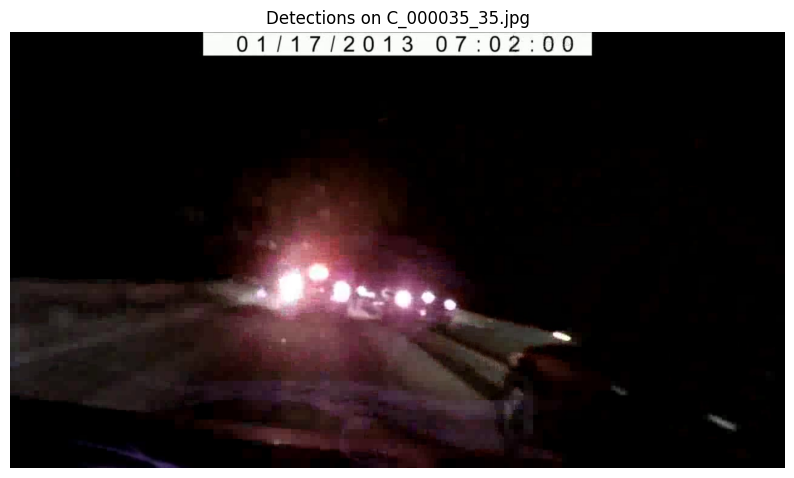


image 1/1 /content/yolo_data/images/C_001419_39.jpg: 384x640 6 cars, 1 bus, 10.6ms
Speed: 2.2ms preprocess, 10.6ms inference, 7.8ms postprocess per image at shape (1, 3, 384, 640)


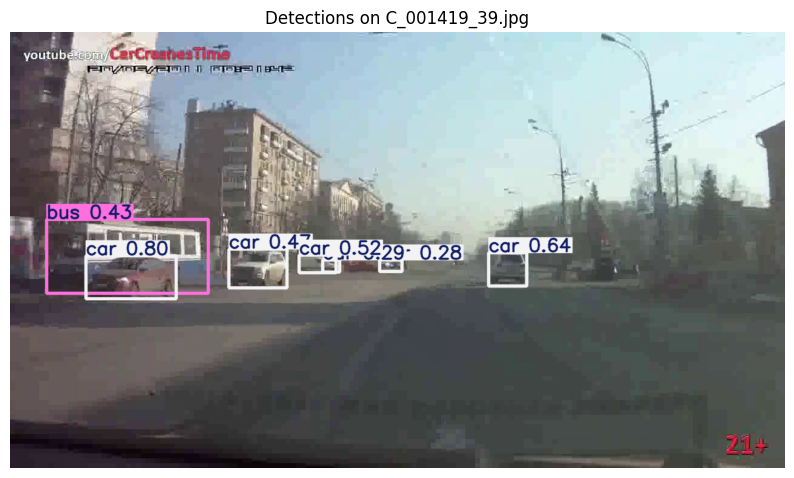


image 1/1 /content/yolo_data/images/C_000171_50.jpg: 384x640 (no detections), 16.1ms
Speed: 4.1ms preprocess, 16.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


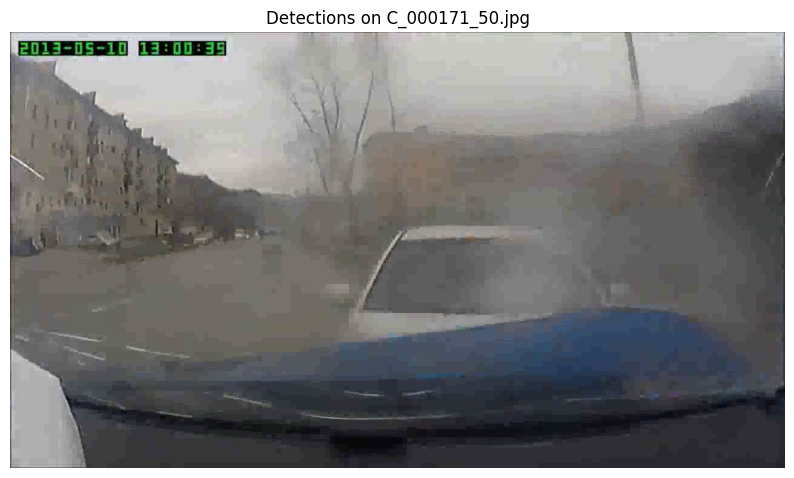


image 1/1 /content/yolo_data/images/C_001339_20.jpg: 384x640 1 car, 1 truck, 1 boat, 8.9ms
Speed: 2.1ms preprocess, 8.9ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


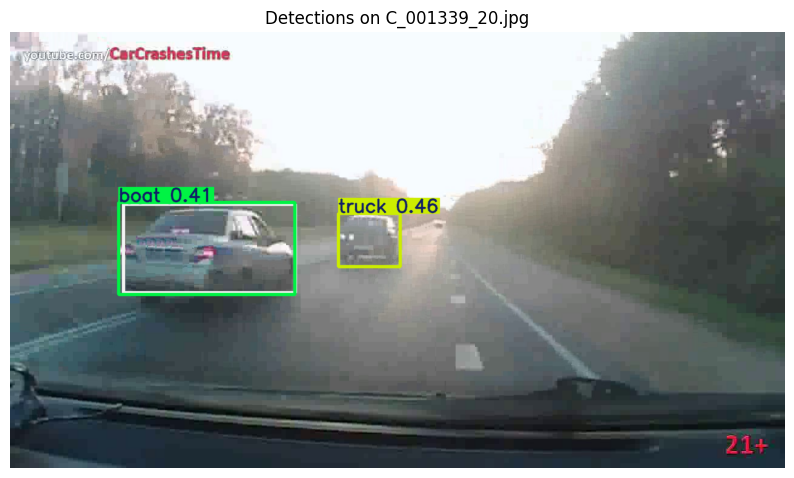


image 1/1 /content/yolo_data/images/C_000657_07.jpg: 384x640 3 cars, 10.8ms
Speed: 2.1ms preprocess, 10.8ms inference, 9.9ms postprocess per image at shape (1, 3, 384, 640)


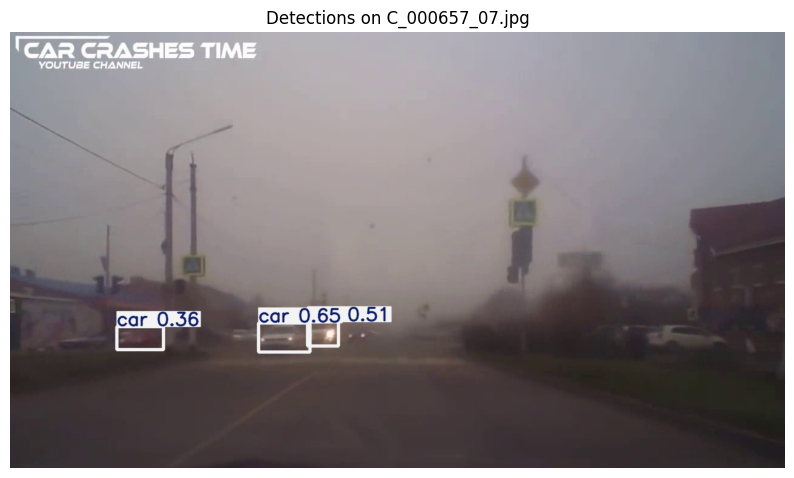

In [ ]:
import os
import glob
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

yolo_model_path = './runs/detect/train3/weights/best.pt'
if not os.path.exists(yolo_model_path):
    print(f"Error: Trained YOLOv8 model not found at {yolo_model_path}.")
    # Fallback to the initial pre-trained model if the trained one is not found
    print("Using pre-trained yolov8n.pt for inference.")
    yolo_model_path = 'yolov8n.pt'

try:
    yolo_model = YOLO(yolo_model_path)
    print(f"Successfully loaded YOLOv8 model from {yolo_model_path}")
except Exception as e:
    print(f"Error loading YOLOv8 model: {e}")
    yolo_model = None


if yolo_model:
    # Define path to the images used for training
    yolo_data_images_path = './yolo_data/images'

    # Get a list of image files
    image_files = glob.glob(os.path.join(yolo_data_images_path, '*.jpg'))

    if not image_files:
        print(f"Error: No image files found in {yolo_data_images_path} to visualize.")
    else:
        print(f"Found {len(image_files)} images for visualization.")

        # Select a few sample images (e.g., first 5)
        sample_image_files = image_files[:5]

        print(f"\nRunning inference and visualizing results for {len(sample_image_files)} sample images...")

        for image_file in sample_image_files:
            try:
                # Run inference
                results = yolo_model(image_file)

                # Plot the results on the image
                annotated_img = results[0].plot()

                # Convert the annotated image from BGR (cv2 default) to RGB (matplotlib default)
                annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

                # Display the annotated image
                plt.figure(figsize=(10, 10))
                plt.imshow(annotated_img_rgb)
                plt.title(f"Detections on {os.path.basename(image_file)}")
                plt.axis('off')
                plt.show()

            except Exception as e:
                print(f"Error processing or visualizing image {image_file}: {e}")

else:
    print("\nSkipping visualization because YOLOv8 model could not be loaded.")